In [ ]:
import argparse
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import wandb
import json
from matplotlib.colors import ListedColormap

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
ENTITY  = "behzadshomali"
PROJECT = "nemotron_MATH_PartialMTP_Gating"

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":      "dejavuserif",
    "font.size":             8,
    "axes.titlesize":        8,
    "axes.labelsize":        8,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":       7,
    "ytick.labelsize":       7,
    "axes.linewidth":        0.7,
    "xtick.major.width":     0.5,
    "ytick.major.width":     0.5,
    "lines.linewidth":       1.2,
    "figure.dpi":            200,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
})

# Shared palette / output dir for all paper figures.
PALETTE   = [plt.cm.viridis(v) for v in np.linspace(0.15, 0.75, 2)]
COL_PRI   = PALETTE[0]
COL_SEC   = PALETTE[1]
PLOTS_DIR = Path("/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
out_dir   = PLOTS_DIR  # backwards-compatible alias used by later cells


def _emnlp_ax(ax, ygrid=True):
    """Apply the shared EMNLP single-column axis cosmetics."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=2, pad=1.5)
    if ygrid:
        ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
        ax.set_axisbelow(True)

In [ ]:
# RUN_IDS = {
#     "$k=3$": "/raid/s3/opengptx/behzad_shomali/benchmarks_full_v1/jvuga5yf/step_27960/task-000-gsm8k::olmes-predictions.jsonl",
#     "$k=5$": "/raid/s3/opengptx/behzad_shomali/benchmarks_full_v1/7sltcsf3/step_27960/task-000-gsm8k::olmes-predictions.jsonl",
#     "$k=7$": "/raid/s3/opengptx/behzad_shomali/modalities/olmes/benchmarks_full_v1_LEONARDO/tx0jvfpe/step_27960/task-000-gsm8k::olmes-predictions.jsonl",
#     "$k=9$": "/raid/s3/opengptx/behzad_shomali/benchmarks_full_v1/t62gpsx1/step_27960/task-000-gsm8k::olmes-predictions.jsonl",
# }

RUN_IDS = {
    "$k=3$": "/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop3.jsonl",
    "$k=7$": "/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop7.jsonl",
    "$k=11$": "/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop11.jsonl",
    "$k=15$": "/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop15.jsonl",
}


In [82]:
with open("/raid/s3/opengptx/behzad_shomali/modalities/olmes/benchmarks_full_v1_LEONARDO/tx0jvfpe/step_27960/task-000-gsm8k::olmes-predictions.jsonl") as f:
    data = [json.loads(line) for line in f]
    

In [83]:
data

[{'doc_id': 0,
  'native_id': 0,
  'metrics': {'exact_match': 0.0,
   'max_tokens_reached': False,
   'num_tokens': 87},
  'model_output': [{'continuation': " Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. So she eats 3 x 4 = 12 eggs per day. So she eats 12 eggs per day. She sells the remainder at the farmers' market for $2 per fresh duck egg. So she sells 12 x 2 = $24. So the answer is $24.",
    'sum_logits': -26.73187035406363,
    'num_tokens': 87,
    'continuation_raw': " Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. So she eats 3 x 4 = 12 eggs per day. So she eats 12 eggs per day. She sells the remainder at the farmers' market for $2 per fresh duck egg. So she sells 12 x 2 = $24. So the answer is $24.\n\n",
    'model_answer': '24'}],
  'label': '18',
  'task_hash': '78b4ca9e4a354a82fb7b847d3afa707d',
  'mode

# Cross-loop recoverability analysis

For each sample (doc_id) we record `exact_match` under every loop count L ∈ {3, 5, 7, 9}.

A **recoverable** sample is one that is wrong in at least one loop *and* correct in at least one other loop — i.e. the model "could have" gotten it right with a different L.

The output below contains:
- A 2-D heatmap of pairwise corrections: `cell[i, j]` = # samples wrong under `L_i` but right under `L_j`.
- A bar chart of per-loop accuracy.
- A bar chart of "recovery rate": of the mistakes made by `L_i`, what fraction is fixed by *any* other loop.
- A breakdown by the number of loops a sample is correct in (0/1/2/3/4).
- A JSON dump of doc_ids per category, written under `loop_MTP_paper/data/recoverability/`.

In [84]:
# ---------------------------------------------------------------------------
# 1. Load every loop's predictions and join into one tidy dataframe.
#    Each row = (doc_id, label, {L: exact_match}, {L: model_answer}, {L: continuation})
# ---------------------------------------------------------------------------
LOOP_KEYS = list(RUN_IDS.keys())  # ['L=3', 'L=5', 'L=7', 'L=9']

per_loop = {}
for k, path in RUN_IDS.items():
    with open(path) as f:
        rows = [json.loads(line) for line in f]
    per_loop[k] = {r["doc_id"]: r for r in rows}
    print(f"{k}: {len(rows):4d} predictions  ({path})")

# Sanity check: all loops share the same doc_id set.
doc_ids = sorted(set.intersection(*(set(d.keys()) for d in per_loop.values())))
assert all(len(d) == len(doc_ids) for d in per_loop.values()), "doc_id sets differ across loops"
print(f"\nShared doc_ids: {len(doc_ids)}")

# Build a long dataframe.
records = []
for did in doc_ids:
    label = per_loop[LOOP_KEYS[0]][did]["label"]
    rec = {"doc_id": did, "label": label}
    for k in LOOP_KEYS:
        r = per_loop[k][did]
        rec[f"em_{k}"]   = int(r["metrics"]["exact_match"])
        rec[f"ans_{k}"]  = r["model_output"][0]["model_answer"]
        rec[f"toks_{k}"] = r["metrics"]["num_tokens"]
        rec[f"maxtok_{k}"] = bool(r["metrics"]["max_tokens_reached"])
    records.append(rec)

df = pd.DataFrame(records).set_index("doc_id")
em_cols = [f"em_{k}" for k in LOOP_KEYS]
df["n_correct"]   = df[em_cols].sum(axis=1)
df["any_correct"] = df["n_correct"] > 0
df["all_correct"] = df["n_correct"] == len(LOOP_KEYS)

print("\nPer-loop accuracy:")
for k in LOOP_KEYS:
    acc = df[f"em_{k}"].mean()
    print(f"  {k}: {acc*100:6.2f}%   ({int(df[f'em_{k}'].sum())}/{len(df)})")
print(f"\nFraction solved by at least one loop:  {df['any_correct'].mean()*100:6.2f}%")
print(f"Fraction solved by ALL loops:         {df['all_correct'].mean()*100:6.2f}%")
print(f"Fraction never solved by any loop:    {(1 - df['any_correct'].mean())*100:6.2f}%")

df.head()

$k=3$: 1319 predictions  (/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop3.jsonl)
$k=7$: 1319 predictions  (/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop7.jsonl)
$k=11$: 1319 predictions  (/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop11.jsonl)
$k=15$: 1319 predictions  (/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop15.jsonl)

Shared doc_ids: 1319

Per-loop accuracy:
  $k=3$:  12.81%   (169/1319)
  $k=7$:  18.12%   (239/1319)
  $k=11$:  15.92%   (210/1319)
  $k=15$:  19.03%   (251/1319)

Fraction solved by at least one loop:   34.72%
Fraction solved by ALL loops:           4.02%
Fraction never solved by any loop:     65.28%


,label,em_$k=3$,ans_$k=3$,toks_$k=3$,maxtok_$k=3$,em_$k=7$,ans_$k=7$,toks_$k=7$,maxtok_$k=7$,em_$k=11$,ans_$k=11$,toks_$k=11$,maxtok_$k=11$,em_$k=15$,ans_$k=15$,toks_$k=15$,maxtok_$k=15$,n_correct,any_correct,all_correct
doc_id,,,,,,,,,,,,,,,,,,,,
0,18,0,136,104,False,0,16,512,True,0,96,77,False,1,18,88,False,1,True,False
1,3,1,3,36,False,1,3,31,False,1,3,31,False,1,3,28,False,4,True,True
2,70000,0,115000,119,False,0,195000,91,False,0,195000,89,False,0,115000,93,False,0,False,False
3,540,0,180,32,False,1,540,34,False,0,180,27,False,0,180,36,False,1,True,False
4,20,0,40,57,False,0,51,512,True,0,40,64,False,0,40,58,False,0,False,False


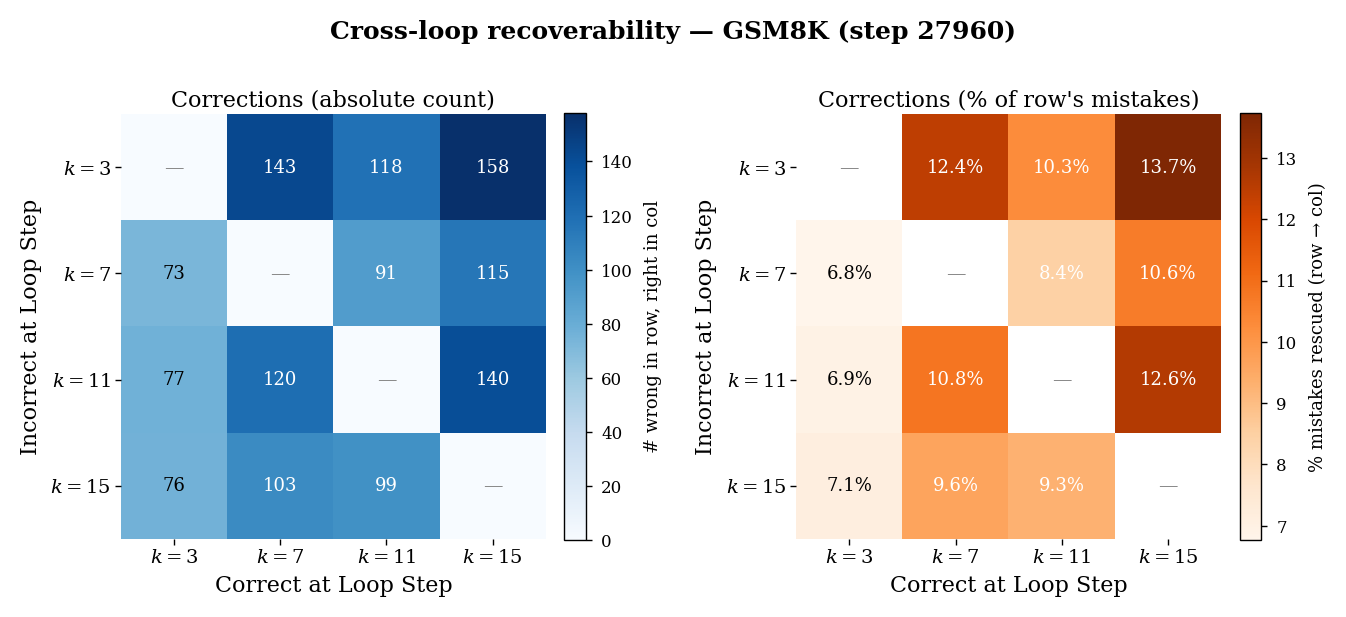


Absolute pairwise correction counts:
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0    143     118     158
$k=7$      73      0      91     115
$k=11$     77    120       0     140
$k=15$     76    103      99       0

As % of row-loop's mistakes:
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN  12.43   10.26   13.74
$k=7$    6.76    NaN    8.43   10.65
$k=11$   6.94  10.82     NaN   12.62
$k=15$   7.12   9.64    9.27     NaN


In [85]:
# ---------------------------------------------------------------------------
# 2. Pairwise "correction" heatmap.
#    M[i, j] = # samples WRONG under L_i but CORRECT under L_j     (i = row, j = col)
#    Diagonal is set to NaN (a loop cannot rescue itself).
# ---------------------------------------------------------------------------
n = len(LOOP_KEYS)
M_count = np.zeros((n, n), dtype=int)
M_pct_of_wrong_i = np.full((n, n), np.nan)   # normalized by # wrongs in row i

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    n_wrong_i = int(wrong_mask[ki].sum())
    for j, kj in enumerate(LOOP_KEYS):
        if i == j:
            continue
        cnt = int((wrong_mask[ki] & right_mask[kj]).sum())
        M_count[i, j] = cnt
        if n_wrong_i:
            M_pct_of_wrong_i[i, j] = cnt / n_wrong_i * 100.0

# Double-column figure (~6.6in wide).
fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.8))

def _heat(ax, mat, title, fmt, cmap, cbar_label):
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_xticklabels(LOOP_KEYS)
    ax.set_yticks(range(n)); ax.set_yticklabels(LOOP_KEYS)
    ax.set_xlabel("Correct at Loop Step", labelpad=3)
    ax.set_ylabel("Incorrect at Loop Step", labelpad=3)
    ax.set_title(title, pad=3)
    for i in range(n):
        for j in range(n):
            if i == j:
                ax.text(j, i, "—", ha="center", va="center", color="gray", fontsize=7)
            else:
                v = mat[i, j]
                if np.isnan(v):
                    continue
                ax.text(j, i, fmt.format(v), ha="center", va="center",
                        color="white" if v > np.nanmax(mat) * 0.55 else "black",
                        fontsize=6.5)
    ax.tick_params(length=2, pad=1.5)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label, fontsize=6.5)
    cb.ax.tick_params(labelsize=6, length=2)
    cb.outline.set_linewidth(0.5)

_heat(axes[0], M_count.astype(float), "Corrections (absolute count)",
      "{:.0f}", "Blues", "# wrong in row, right in col")
_heat(axes[1], M_pct_of_wrong_i,
      "Corrections (% of row's mistakes)",
      "{:.1f}%", "Oranges", "% mistakes rescued (row → col)")

fig.suptitle("Cross-loop recoverability — GSM8K (step 27960)",
             y=1.05, fontsize=9, fontweight="bold")
fig.tight_layout(pad=0.3, w_pad=1.5)

fig.savefig(PLOTS_DIR / "recoverability_pairwise_heatmap.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "recoverability_pairwise_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAbsolute pairwise correction counts:")
print(pd.DataFrame(M_count, index=LOOP_KEYS, columns=LOOP_KEYS))
print("\nAs % of row-loop's mistakes:")
print(pd.DataFrame(M_pct_of_wrong_i, index=LOOP_KEYS, columns=LOOP_KEYS).round(2))

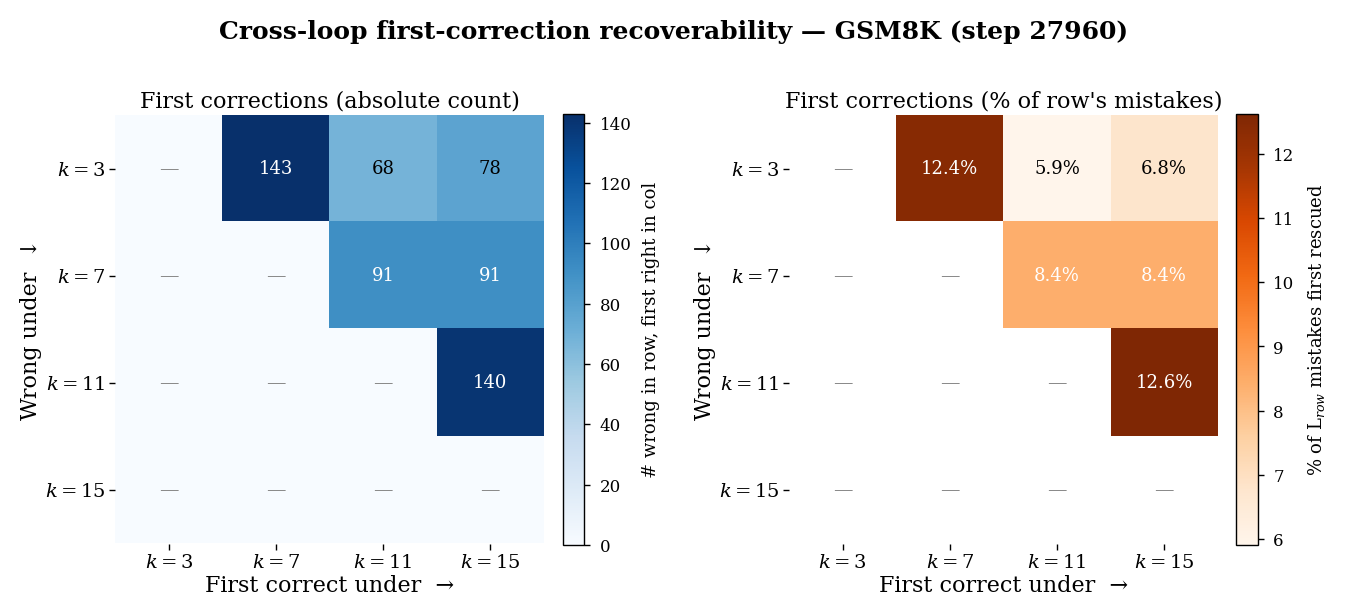


Absolute first-correction counts:
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0    143      68      78
$k=7$       0      0      91      91
$k=11$      0      0       0     140
$k=15$      0      0       0       0

As % of row-loop's mistakes:
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN  12.43    5.91    6.78
$k=7$     NaN    NaN    8.43    8.43
$k=11$    NaN    NaN     NaN   12.62
$k=15$    NaN    NaN     NaN     NaN


In [86]:
# ---------------------------------------------------------------------------
# 2. Pairwise "first-correction" heatmap.
#    M[i, j] = # samples WRONG under L_i, WRONG under every L_k for i < k < j,
#              and CORRECT under L_j     (L_j = first loop after L_i to be correct)
#    Lower triangle + diagonal are NaN (no "later" loop to correct from).
# ---------------------------------------------------------------------------
n = len(LOOP_KEYS)
M_count = np.zeros((n, n), dtype=int)
M_pct_of_wrong_i = np.full((n, n), np.nan)   # normalized by # wrongs in row i

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    n_wrong_i = int(wrong_mask[ki].sum())
    for j, kj in enumerate(LOOP_KEYS):
        if j <= i:
            continue
        # wrong under L_i, wrong under every loop strictly between i and j, right under L_j
        mask = wrong_mask[ki] & right_mask[kj]
        for m in range(i + 1, j):
            mask &= wrong_mask[LOOP_KEYS[m]]
        cnt = int(mask.sum())
        M_count[i, j] = cnt
        if n_wrong_i:
            M_pct_of_wrong_i[i, j] = cnt / n_wrong_i * 100.0

# Double-column figure (~6.6in wide).
fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.8))

def _heat(ax, mat, title, fmt, cmap, cbar_label):
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_xticklabels(LOOP_KEYS)
    ax.set_yticks(range(n)); ax.set_yticklabels(LOOP_KEYS)
    ax.set_xlabel("First correct under  →", labelpad=1)
    ax.set_ylabel("Wrong under  ↓", labelpad=1)
    ax.set_title(title, pad=3)
    for i in range(n):
        for j in range(n):
            if j <= i:
                ax.text(j, i, "—", ha="center", va="center", color="gray", fontsize=7)
            else:
                v = mat[i, j]
                if np.isnan(v):
                    continue
                ax.text(j, i, fmt.format(v), ha="center", va="center",
                        color="white" if v > np.nanmax(mat) * 0.55 else "black",
                        fontsize=6.5)
    ax.tick_params(length=2, pad=1.5)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label, fontsize=6.5)
    cb.ax.tick_params(labelsize=6, length=2)
    cb.outline.set_linewidth(0.5)

_heat(axes[0], M_count.astype(float), "First corrections (absolute count)",
      "{:.0f}", "Blues", "# wrong in row, first right in col")
_heat(axes[1], M_pct_of_wrong_i,
      "First corrections (% of row's mistakes)",
      "{:.1f}%", "Oranges", "% of L$_{row}$ mistakes first rescued")

fig.suptitle("Cross-loop first-correction recoverability — GSM8K (step 27960)",
             y=1.05, fontsize=9, fontweight="bold")
fig.tight_layout(pad=0.3, w_pad=1.5)

fig.savefig(PLOTS_DIR / "recoverability_first_pairwise_heatmap.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "recoverability_first_pairwise_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAbsolute first-correction counts:")
print(pd.DataFrame(M_count, index=LOOP_KEYS, columns=LOOP_KEYS))
print("\nAs % of row-loop's mistakes:")
print(pd.DataFrame(M_pct_of_wrong_i, index=LOOP_KEYS, columns=LOOP_KEYS).round(2))

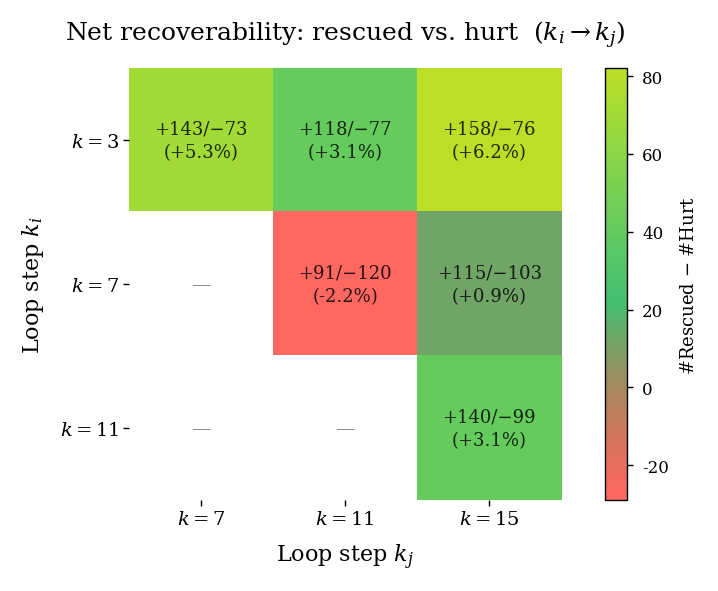


Total samples (denominator for %): 1319

Rescued counts (wrong@row -> right@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0    143     118     158
$k=7$       0      0      91     115
$k=11$      0      0       0     140
$k=15$      0      0       0       0

Hurt counts (right@row -> wrong@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0     73      77      76
$k=7$       0      0     120     103
$k=11$      0      0       0      99
$k=15$      0      0       0       0

Net (rescued - hurt):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   70.0    41.0    82.0
$k=7$     NaN    NaN   -29.0    12.0
$k=11$    NaN    NaN     NaN    41.0
$k=15$    NaN    NaN     NaN     NaN

Rescued % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN  10.84    8.95   11.98
$k=7$     NaN    NaN    6.90    8.72
$k=11$    NaN    NaN     NaN   10.61
$k=15$    NaN    NaN     NaN     NaN

Hurt % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   5.53   

In [87]:
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ---------------------------------------------------------------------------
# 3. Pairwise NET recoverability heatmap (rescued vs hurt).
# ---------------------------------------------------------------------------

n = len(LOOP_KEYS)
N = len(df)

M_rescued = np.zeros((n, n), dtype=int)
M_hurt    = np.zeros((n, n), dtype=int)
M_net     = np.full((n, n), np.nan)

M_rescued_pct = np.full((n, n), np.nan)
M_hurt_pct    = np.full((n, n), np.nan)

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    for j, kj in enumerate(LOOP_KEYS):
        if j <= i:
            continue
        r = int((wrong_mask[ki] & right_mask[kj]).sum())
        h = int((right_mask[ki] & wrong_mask[kj]).sum())
        M_rescued[i, j] = r
        M_hurt[i, j]    = h
        M_net[i, j]     = r - h
        M_rescued_pct[i, j] = r / N * 100.0
        M_hurt_pct[i, j]    = h / N * 100.0


# ---------------------------------------------------------------------------
# Drop the always-empty first column (j=0) and last row (i=n-1).
# ---------------------------------------------------------------------------
net_view = M_net[:-1, 1:]
x_labels = LOOP_KEYS[1:]
y_labels = LOOP_KEYS[:-1]

vmin = float(np.nanmin(net_view))
vmax = float(np.nanmax(net_view))
vmin = min(vmin, -1e-9)
vmax = max(vmax,  1e-9)

# ---------------------------------------------------------------------------
# Linear normalization (NOT TwoSlopeNorm). Zero sits at its true proportional
# position on the bar -> short red section, long green section.
# ---------------------------------------------------------------------------
norm = Normalize(vmin=vmin, vmax=vmax)

# Build the colormap so its red->green transition aligns with 0 in data space.
zero_frac = (0.0 - vmin) / (vmax - vmin)   # fraction of bar below 0
n_total = 256
n_neg = max(1, int(round(zero_frac * n_total)))
n_pos = n_total - n_neg

pos_colors = plt.cm.viridis(np.linspace(0.7, 0.9, 80))
neg_anchor = pos_colors[0]
neg_colors = LinearSegmentedColormap.from_list(
    "neg", ["#ff0d009f", neg_anchor]
)(np.linspace(0, 1, n_neg))
cmap = LinearSegmentedColormap.from_list(
    "viridis_div_red", np.vstack([neg_colors, pos_colors])
)

# ---------------------------------------------------------------------------
# Plot.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6.0, 3.0))
im = ax.imshow(net_view, cmap=cmap, norm=norm)

rows, cols = net_view.shape
ax.set_xticks(range(cols)); ax.set_xticklabels(x_labels)
ax.set_yticks(range(rows)); ax.set_yticklabels(y_labels)
ax.set_xlabel(r"Loop step $k_j$", labelpad=5)
ax.set_ylabel(r"Loop step $k_i$", labelpad=5)
ax.set_title("Net recoverability: rescued vs. hurt  ($k_i \\to k_j$)",
             fontsize=9, pad=10)

for i in range(rows):
    for j in range(cols):
        orig_i = i
        orig_j = j + 1
        if orig_j <= orig_i:
            ax.text(j, i, "—", ha="center", va="center",
                    color="gray", fontsize=7)
            continue
        net = M_net[orig_i, orig_j]
        if np.isnan(net):
            continue
        txt_color = "#000000D2"
        net_pct = net / N * 100.0
        ax.text(
            j, i,
            f"+{M_rescued[orig_i, orig_j]}/−{M_hurt[orig_i, orig_j]}\n"
            f"({net_pct:+.1f}%)",
            ha="center", va="center", color=txt_color, fontsize=6.5,
            linespacing=1.4,
        )

ax.tick_params(length=2, pad=1.5)
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------------------------------------------------------------
# Colorbar: evenly spaced ticks every `tick_step` units across the whole bar.
# Zero is naturally included; spacing is uniform in data units.
# ---------------------------------------------------------------------------
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("#Rescued $-$ #Hurt", fontsize=6.5)

tick_step = 20   # change to 10 / 25 to taste
cb.ax.yaxis.set_major_locator(MultipleLocator(tick_step))
cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}"))
cb.ax.tick_params(labelsize=6, length=2)
cb.outline.set_linewidth(0.5)

fig.tight_layout()

fig.savefig(PLOTS_DIR / "recoverability_net_pairwise_heatmap.pdf",
            bbox_inches="tight")
fig.savefig(PLOTS_DIR / "recoverability_net_pairwise_heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# Print tables
# ---------------------------------------------------------------------------
idx, col = LOOP_KEYS, LOOP_KEYS
print(f"\nTotal samples (denominator for %): {N}")
print("\nRescued counts (wrong@row -> right@col):")
print(pd.DataFrame(M_rescued, index=idx, columns=col))
print("\nHurt counts (right@row -> wrong@col):")
print(pd.DataFrame(M_hurt, index=idx, columns=col))
print("\nNet (rescued - hurt):")
print(pd.DataFrame(M_net, index=idx, columns=col))
print("\nRescued % (of all samples):")
print(pd.DataFrame(M_rescued_pct, index=idx, columns=col).round(2))
print("\nHurt % (of all samples):")
print(pd.DataFrame(M_hurt_pct, index=idx, columns=col).round(2))

        accuracy_%  n_correct  n_wrong  n_recoverable  recovery_rate_%
loop                                                                  
$k=3$        12.81        169     1150            289            25.13
$k=7$        18.12        239     1080            219            20.28
$k=11$       15.92        210     1109            248            22.36
$k=15$       19.03        251     1068            207            19.38


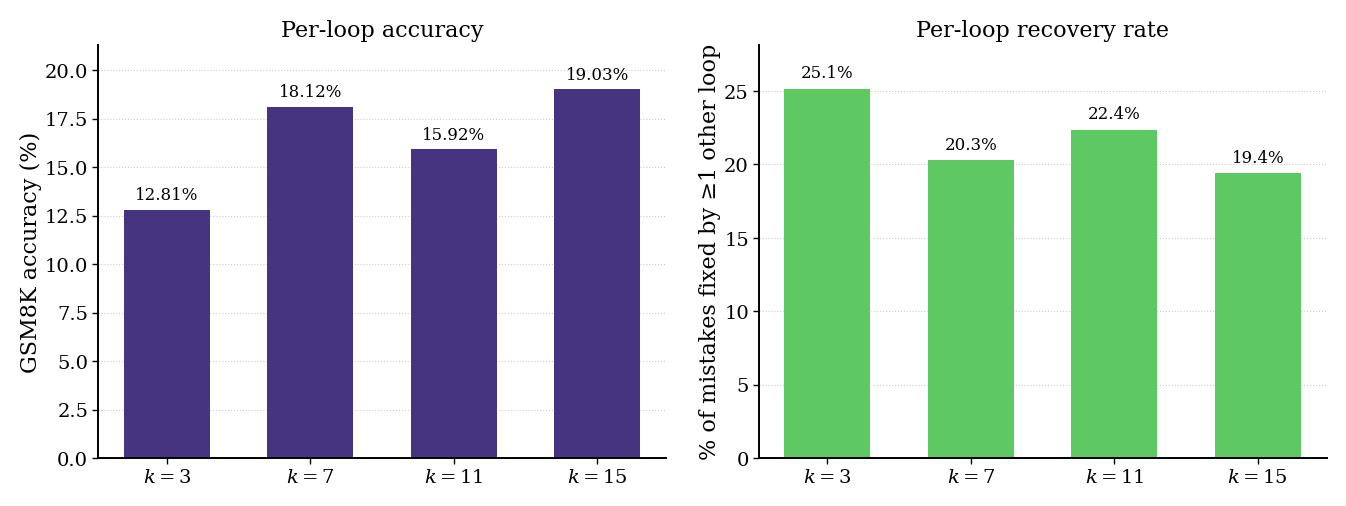

In [88]:
# ---------------------------------------------------------------------------
# 3. Per-loop summary: accuracy, # mistakes, fraction of mistakes recoverable
#    by at least one OTHER loop ("any-other recovery rate").
# ---------------------------------------------------------------------------
summary = []
for k in LOOP_KEYS:
    wrong_k = wrong_mask[k]
    rescued_by_other = wrong_k & (df[[f"em_{kk}" for kk in LOOP_KEYS if kk != k]].sum(axis=1) > 0)
    summary.append({
        "loop": k,
        "accuracy_%": df[f"em_{k}"].mean() * 100,
        "n_correct": int(df[f"em_{k}"].sum()),
        "n_wrong":   int(wrong_k.sum()),
        "n_recoverable":   int(rescued_by_other.sum()),
        "recovery_rate_%": rescued_by_other.sum() / max(wrong_k.sum(), 1) * 100,
    })
summary_df = pd.DataFrame(summary).set_index("loop")
print(summary_df.round(2))

# Double-column figure (~6.6in wide).
fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.4))

axes[0].bar(LOOP_KEYS, summary_df["accuracy_%"], color=COL_PRI, width=0.6, zorder=2)
axes[0].set_ylabel("GSM8K accuracy (%)", labelpad=1)
axes[0].set_title("Per-loop accuracy", pad=3)
for i, v in enumerate(summary_df["accuracy_%"]):
    axes[0].text(i, v + 0.3, f"{v:.2f}%", ha="center", va="bottom", fontsize=6)

axes[1].bar(LOOP_KEYS, summary_df["recovery_rate_%"], color=COL_SEC, width=0.6, zorder=2)
axes[1].set_ylabel("% of mistakes fixed by ≥1 other loop", labelpad=1)
axes[1].set_title("Per-loop recovery rate", pad=3)
for i, v in enumerate(summary_df["recovery_rate_%"]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=6)

for ax in axes:
    _emnlp_ax(ax)
    ax.margins(y=0.12)

fig.tight_layout(pad=0.3, w_pad=1.5)
fig.savefig(PLOTS_DIR / "recoverability_per_loop_summary.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "recoverability_per_loop_summary.png", dpi=300, bbox_inches="tight")
plt.show()

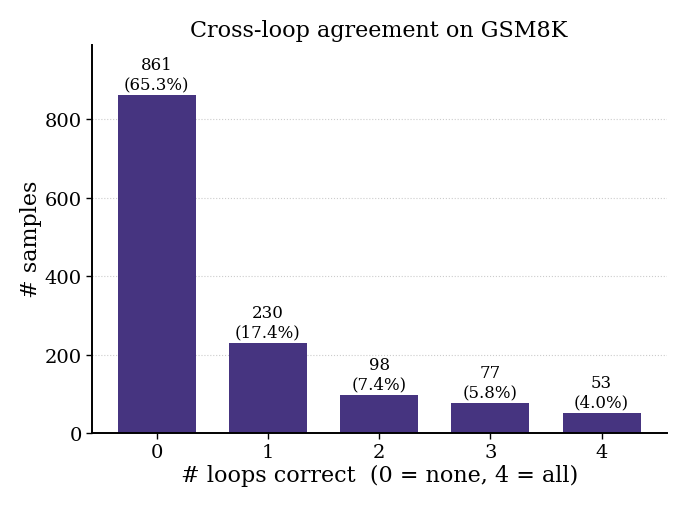


Samples never solved (n_correct == 0): 861  (65.28%)
Samples always solved (n_correct == 4): 53  (4.02%)
Samples 'recoverable' (mixed wrong+right across loops): 405  (30.71%)


In [89]:
# ---------------------------------------------------------------------------
# 4. How many loops solve each sample? (Distribution of agreement)
# ---------------------------------------------------------------------------
dist = df["n_correct"].value_counts().sort_index()
dist_pct = dist / len(df) * 100

# Single text-column figure (~3.3in wide).
fig, ax = plt.subplots(figsize=(3.3, 2.4))
bars = ax.bar(dist.index.astype(str), dist.values, color=COL_PRI, width=0.7, zorder=2)
ax.set_xlabel(f"# loops correct  (0 = none, {len(LOOP_KEYS)} = all)", labelpad=1)
ax.set_ylabel("# samples", labelpad=1)
ax.set_title("Cross-loop agreement on GSM8K", pad=3)
for b, p in zip(bars, dist_pct.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 5,
            f"{int(b.get_height())}\n({p:.1f}%)", ha="center", va="bottom", fontsize=6)
_emnlp_ax(ax)
ax.margins(y=0.15)
fig.tight_layout(pad=0.3)
fig.savefig(PLOTS_DIR / "recoverability_n_correct_distribution.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "recoverability_n_correct_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSamples never solved (n_correct == 0): "
      f"{int((df['n_correct']==0).sum())}  ({(df['n_correct']==0).mean()*100:.2f}%)")
print(f"Samples always solved (n_correct == {len(LOOP_KEYS)}): "
      f"{int(df['all_correct'].sum())}  ({df['all_correct'].mean()*100:.2f}%)")
print(f"Samples 'recoverable' (mixed wrong+right across loops): "
      f"{int(((df['n_correct']>0)&(df['n_correct']<len(LOOP_KEYS))).sum())}  "
      f"({((df['n_correct']>0)&(df['n_correct']<len(LOOP_KEYS))).mean()*100:.2f}%)")

In [90]:
# ---------------------------------------------------------------------------
# 5. Correctness-pattern table.
#    Every sample has a 4-bit pattern over (L=3, L=5, L=7, L=9).
#    1 = correct, 0 = wrong. We list every pattern and how many samples it has.
# ---------------------------------------------------------------------------
def _pattern(row):
    return "".join(str(int(row[f"em_{k}"])) for k in LOOP_KEYS)

df["pattern"] = df.apply(_pattern, axis=1)

pat_counts = (
    df.groupby("pattern")
      .size()
      .rename("n_samples")
      .reset_index()
      .assign(pct=lambda x: x["n_samples"] / len(df) * 100)
      .sort_values("n_samples", ascending=False)
)
pat_counts["legend"] = pat_counts["pattern"].apply(
    lambda p: " ".join(f"{k}={'✓' if c=='1' else '✗'}" for k, c in zip(LOOP_KEYS, p))
)
print(pat_counts.to_string(index=False))

pattern  n_samples       pct                            legend
   0000        861 65.276725 $k=3$=✗ $k=7$=✗ $k=11$=✗ $k=15$=✗
   0001         78  5.913571 $k=3$=✗ $k=7$=✗ $k=11$=✗ $k=15$=✓
   0100         58  4.397271 $k=3$=✗ $k=7$=✓ $k=11$=✗ $k=15$=✗
   0010         57  4.321456 $k=3$=✗ $k=7$=✗ $k=11$=✓ $k=15$=✗
   1111         53  4.018196 $k=3$=✓ $k=7$=✓ $k=11$=✓ $k=15$=✓
   1000         37  2.805155 $k=3$=✓ $k=7$=✗ $k=11$=✗ $k=15$=✗
   0101         35  2.653525 $k=3$=✗ $k=7$=✓ $k=11$=✗ $k=15$=✓
   0111         34  2.577710 $k=3$=✗ $k=7$=✓ $k=11$=✓ $k=15$=✓
   1110         16  1.213040 $k=3$=✓ $k=7$=✓ $k=11$=✓ $k=15$=✗
   0110         16  1.213040 $k=3$=✗ $k=7$=✓ $k=11$=✓ $k=15$=✗
   1101         14  1.061410 $k=3$=✓ $k=7$=✓ $k=11$=✗ $k=15$=✓
   1001         13  0.985595 $k=3$=✓ $k=7$=✗ $k=11$=✗ $k=15$=✓
   1100         13  0.985595 $k=3$=✓ $k=7$=✓ $k=11$=✗ $k=15$=✗
   1011         13  0.985595 $k=3$=✓ $k=7$=✗ $k=11$=✓ $k=15$=✓
   0011         11  0.833965 $k=3$=✗ $k=7$=✗ $k=11$=✓ $

Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], 

Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], 

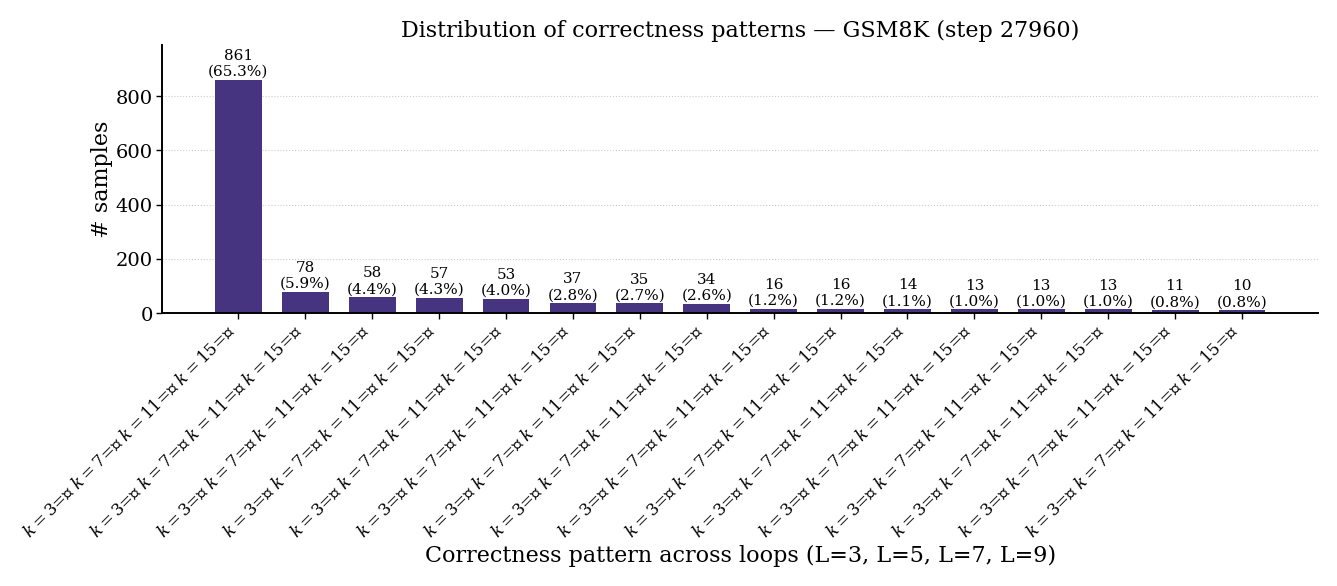

In [91]:
# plot pat_counts
# Double-column figure (~6.6in wide); many bars need the width.
fig, ax = plt.subplots(figsize=(6.6, 2.8))
bars = ax.bar(pat_counts["legend"], pat_counts["n_samples"], color=COL_PRI,
              width=0.7, zorder=2)
ax.set_xlabel("Correctness pattern across loops (L=3, L=5, L=7, L=9)", labelpad=1)
ax.set_ylabel("# samples", labelpad=1)
ax.set_title("Distribution of correctness patterns — GSM8K (step 27960)", pad=3)
ax.set_xticks(range(len(pat_counts)))
ax.set_xticklabels(pat_counts["legend"], rotation=45, ha="right", fontsize=6)
for b, p in zip(bars, pat_counts["pct"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 5,
            f"{int(b.get_height())}\n({p:.1f}%)", ha="center", va="bottom", fontsize=5.5)
_emnlp_ax(ax)
ax.margins(y=0.15)
fig.tight_layout(pad=0.3)
fig.savefig(PLOTS_DIR / "correctness_pattern_bars.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "correctness_pattern_bars.png", dpi=300, bbox_inches="tight")
plt.show()

In [92]:
# ---------------------------------------------------------------------------
# 6. Persist sample indices for manual inspection.
#    Per-loop:   wrong_only_under_L / rescued_by_any_other / never_rescued
#    Pairwise:   wrong_in_L_i__right_in_L_j
#    Plus full tidy CSV for downstream filtering.
# ---------------------------------------------------------------------------
inspect_dir = Path("/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/data/recoverability")
inspect_dir.mkdir(parents=True, exist_ok=True)

indices = {"per_loop": {}, "pairwise": {}, "global": {}}

# Per-loop recoverable / never-rescued docs.
for k in LOOP_KEYS:
    wrong_k = wrong_mask[k]
    rescued = wrong_k & (df[[f"em_{kk}" for kk in LOOP_KEYS if kk != k]].sum(axis=1) > 0)
    never   = wrong_k & ~(df[[f"em_{kk}" for kk in LOOP_KEYS if kk != k]].sum(axis=1) > 0)
    indices["per_loop"][k] = {
        "wrong_doc_ids":          df.index[wrong_k].tolist(),
        "rescued_by_other_doc_ids": df.index[rescued].tolist(),
        "never_rescued_doc_ids":  df.index[never].tolist(),
    }

# Pairwise: wrong_in_i AND right_in_j.
for i, ki in enumerate(LOOP_KEYS):
    for j, kj in enumerate(LOOP_KEYS):
        if i == j:
            continue
        ids = df.index[wrong_mask[ki] & right_mask[kj]].tolist()
        indices["pairwise"][f"wrong_in_{ki}__right_in_{kj}"] = ids

# Global slices.
indices["global"] = {
    "never_solved_doc_ids":  df.index[df["n_correct"] == 0].tolist(),
    "always_solved_doc_ids": df.index[df["all_correct"]].tolist(),
    "recoverable_doc_ids":   df.index[(df["n_correct"] > 0) & (df["n_correct"] < len(LOOP_KEYS))].tolist(),
}

with open(inspect_dir / "indices.json", "w") as f:
    json.dump(indices, f, indent=2)

# Full tidy CSV.
csv_cols = (["label", "n_correct", "pattern"]
            + [f"em_{k}" for k in LOOP_KEYS]
            + [f"ans_{k}" for k in LOOP_KEYS]
            + [f"toks_{k}" for k in LOOP_KEYS]
            + [f"maxtok_{k}" for k in LOOP_KEYS])
df[csv_cols].to_csv(inspect_dir / "per_sample.csv")

# Pairwise + per-loop summary CSVs.
pd.DataFrame(M_count, index=LOOP_KEYS, columns=LOOP_KEYS).to_csv(inspect_dir / "pairwise_counts.csv")
pd.DataFrame(M_pct_of_wrong_i, index=LOOP_KEYS, columns=LOOP_KEYS).to_csv(inspect_dir / "pairwise_pct_of_row_wrongs.csv")
summary_df.to_csv(inspect_dir / "per_loop_summary.csv")
pat_counts.to_csv(inspect_dir / "pattern_counts.csv", index=False)

print(f"Saved to: {inspect_dir}")
for p in sorted(inspect_dir.iterdir()):
    print(f"  {p.name}")

# Quick example: first 20 recoverable doc_ids (mixed wrong+right across loops).
recov = indices["global"]["recoverable_doc_ids"]
print(f"\n{len(recov)} recoverable doc_ids in total. First 20:")
print(recov[:20])

Saved to: /raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/data/recoverability
  indices.json
  pairwise_counts.csv
  pairwise_pct_of_row_wrongs.csv
  pattern_counts.csv
  per_loop_summary.csv
  per_sample.csv

405 recoverable doc_ids in total. First 20:
[0, 3, 6, 11, 16, 19, 20, 23, 24, 28, 32, 34, 35, 42, 49, 53, 55, 56, 61, 69]


In [93]:
# ---------------------------------------------------------------------------
# 7. Helper to pretty-print a single doc across all loops for manual review.
#    Use: show_doc(123)  or  show_doc(indices["pairwise"]["wrong_in_L=3__right_in_L=7"][0])
# ---------------------------------------------------------------------------
def show_doc(did: int, max_chars: int = 600):
    print(f"=== doc_id={did}    gold label = {per_loop[LOOP_KEYS[0]][did]['label']} ===")
    for k in LOOP_KEYS:
        r = per_loop[k][did]
        em = r["metrics"]["exact_match"]
        ans = r["model_output"][0]["model_answer"]
        cont = r["model_output"][0]["continuation"]
        if len(cont) > max_chars:
            cont = cont[:max_chars] + " …[truncated]"
        marker = "✓" if em == 1.0 else "✗"
        print(f"\n[{k}] {marker}  answer={ans!r}   tokens={r['metrics']['num_tokens']}"
              f"   max_tok_reached={r['metrics']['max_tokens_reached']}")
        print(f"    {cont}")

# Example call — first sample wrong in L=3 but right in L=7.
example = indices["pairwise"].get("wrong_in_L=7__right_in_L=9", [])
if example:
    show_doc(example[0])

/tmp/ipykernel_2605341/3519292712.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.02, 1, 0.96])


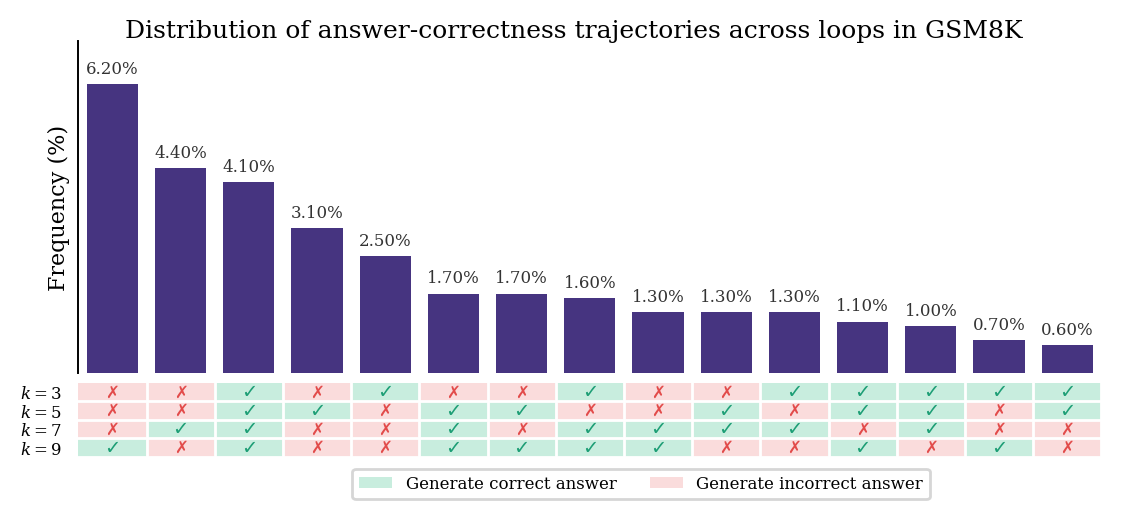

Saved: correctness_heatmap.png, correctness_alluvial.png


In [94]:
"""
Correctness-pattern visualisations for GSM8K (or any multi-loop eval).

Two plots
─────────
1. Heatmap + frequency bar  – replaces the rotated-label bar chart
2. Alluvial / Sankey         – shows sample flow between correct/incorrect across loops

Assumes `pat_counts` is a DataFrame with columns:
    pattern   – tuple of bools, e.g. (True, True, False, True)
    n_samples – int
    pct       – float  (percentage)
    legend    – str    (the old x-axis label, not used here)

Adapt LOOP_LABELS if your loop lengths differ.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import ListedColormap

# ── CONFIG ──────────────────────────────────────────────────────────────
LOOP_LABELS = ["$k=3$", "$k=5$", "$k=7$", "$k=9$"]
TITLE_SUFFIX = "GSM8K (step 27960)"
COL_OK = "#1D9E75"
COL_FAIL = "#E24B4A"
COL_OK_LIGHT = "#C8EDDE"
COL_FAIL_LIGHT = "#FADCDC"
COL_BAR = "#4C72B0"



# ── DEMO DATA  ───────────────────────────
demo_patterns = [
    ((False, False, False, False), 888, 67.3),
    ((False, False, False, True), 82, 6.2),
    ((False, False, True,  False), 58, 4.4),
    ((True,  True,  True,  True),  54, 4.1),
    ((False, True,  False, False), 41, 3.1),
    ((True,  False, False, False), 33, 2.5),
    ((False, True,  True,  True),  23, 1.7),
    ((False, True,  False, True),  23, 1.7),
    ((True,  False, True,  True),  21, 1.6),
    ((False, False, True,  True),  17, 1.3),
    ((False, True,  True,  False), 17, 1.3),
    ((True,  False, True,  False), 17, 1.3),
    ((True,  True,  False, True),  15, 1.1),
    ((True,  True,  True,  False), 13, 1.0),
    ((True,  False, False, True), 9,  0.7),
    ((True,  True,  False, False), 8,  0.6),
][1:]
patterns = [p for p, _, _ in demo_patterns]
n_samples = np.array([n for _, n, _ in demo_patterns])
pcts = np.array([p for _, _, p in demo_patterns])
n_loops = len(LOOP_LABELS)
n_patterns = len(patterns)
total = n_samples.sum()


# ═══════════════════════════════════════════════════════════════════════
# PLOT 1 — Heatmap + horizontal bar
# ═══════════════════════════════════════════════════════════════════════
def plot_heatmap_bar(patterns, n_samples, pcts,
                     loop_labels=LOOP_LABELS, title_suffix=TITLE_SUFFIX):
    n_pat = len(patterns)
    n_lp = len(loop_labels)
    mat = np.array([[0 if v else 1 for v in p] for p in patterns]).T

    fig, (ax_bar, ax_heat) = plt.subplots(
        2, 1, figsize=(max(6.6, n_pat * 0.3), 2.7),
        gridspec_kw={"height_ratios": [18, n_lp], "hspace": 0.05},
        sharex=True
    )

    # ── bar chart ──
    x_pos = np.arange(n_pat)
    ax_bar.bar(x_pos, pcts, color=COL_PRI, width=0.75, zorder=2)

    for i, (x, p, s) in enumerate(zip(x_pos, pcts, n_samples)):
        ax_bar.text(x, p + 0.15, f"{p:.2f}%",
                    ha="center", va="bottom", fontsize=6, color="#333")

    ax_bar.set_xlim(-0.6, n_pat - 0.45)
    ax_bar.set_yticks([])
    ax_bar.set_xticks([])  
    ax_bar.set_ylabel("Frequency (%)", labelpad=3)
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.spines["bottom"].set_visible(False)
    ax_bar.margins(y=0.15)                       # headroom for labels

    # ── heatmap ──
    cmap = ListedColormap([COL_OK_LIGHT, COL_FAIL_LIGHT])
    ax_heat.imshow(mat, cmap=cmap, aspect="auto", vmin=0, vmax=1)

    for i in range(n_lp):
        for j in range(n_pat):
            sym = "✓" if mat[i, j] == 0 else "✗"
            fontsize = 7 if mat[i, j] == 0 else 6
            col = COL_OK if mat[i, j] == 0 else COL_FAIL
            ax_heat.text(j, i, sym, ha="center", va="center",
                         fontsize=fontsize, fontweight="bold", color=col,
                         fontfamily="DejaVu Sans")

    ax_heat.set_yticks(range(n_lp))
    ax_heat.set_yticklabels(loop_labels, fontsize=6)
    ax_heat.set_xticks([])

    ax_heat.tick_params(length=0, pad=6)
    ax_heat.set_xlim(-0.5, n_pat - 0.5)

    for spine in ax_heat.spines.values():
        spine.set_visible(False)

    # grid lines between cells
    for x in np.arange(0.5, n_pat, 1):
        ax_heat.axvline(x, color="white", lw=1.0)
    for y in np.arange(0.5, n_lp, 1):
        ax_heat.axhline(y, color="white", lw=1.0)

    # ── title & legend ──
    fig.suptitle(f"Distribution of answer-correctness trajectories across loops in GSM8K",
                 fontsize=9, y=0.92)

    handles = [
        mpatches.Patch(facecolor=COL_OK_LIGHT, label="Generate correct answer"),
        mpatches.Patch(facecolor=COL_FAIL_LIGHT, label="Generate incorrect answer"),
    ]
    ax_heat.legend(
        handles=handles, 
        loc="upper center",
        bbox_to_anchor=(0.55, -0.05),
        # bbox_to_anchor=(0, -0.18), 
        ncol=2, 
        fontsize=6,
        frameon=True,
        framealpha=0.8,
        edgecolor="#cccccc"
    )

    fig.tight_layout(rect=[0, 0.02, 1, 0.96])
    return fig





# ═══════════════════════════════════════════════════════════════════════
# MAIN — render both plots
# ═══════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    fig1 = plot_heatmap_bar(patterns, n_samples, pcts)
    fig1.savefig(PLOTS_DIR / "correctness_heatmap.pdf", bbox_inches="tight")
    # fig1.savefig(PLOTS_DIR / "correctness_heatmap.png", dpi=300, bbox_inches="tight")

    # fig2 = plot_alluvial(patterns, n_samples)
    # fig2.savefig("correctness_alluvial.png", dpi=180, bbox_inches="tight")

    plt.show()
    print("Saved: correctness_heatmap.png, correctness_alluvial.png")

In [95]:
n_samples

array([82, 58, 54, 41, 33, 23, 23, 21, 17, 17, 17, 15, 13,  9,  8])

In [96]:
"""
Bidirectional alluvial plot for multi-loop evaluations.

Shows per-loop correctness with both rescues (wrong→correct) and
regressions (correct→wrong) between consecutive loop lengths.

Reads ``per_sample.csv`` produced by your eval pipeline.
Requires only matplotlib + numpy + pandas.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path

# ── CONFIG ──────────────────────────────────────────────────────────────
EM_COLS = ["em_L=3", "em_L=5", "em_L=7", "em_L=9"]
STAGE_LABELS = ["L=3", "L=5", "L=7", "L=9"]
TITLE_SUFFIX = "GSM8K (step 27960)"

COL_OK      = "#1D9E75"
COL_FIX     = "#EF9F27"
COL_BROKE   = "#7F77DD"      # purple for regressions
COL_FAIL    = "#E24B4A"

COL_OK_RIB    = (0.11, 0.62, 0.46, 0.20)
COL_FIX_RIB   = (0.94, 0.62, 0.15, 0.35)
COL_BROKE_RIB = (0.50, 0.47, 0.87, 0.30)
COL_FAIL_RIB  = (0.89, 0.29, 0.29, 0.15)


# ── DATA PREP ───────────────────────────────────────────────────────────
def compute_stages_and_flows(df: pd.DataFrame, em_cols: list[str]):
    """
    Returns
    -------
    stages : list[dict]
        Per-stage node sizes: {label, ok, wrong}
    flows  : list[dict]
        Per-transition counts: {stayed_ok, fixed, broke, stayed_wrong}
    """
    total = len(df)
    stages = []
    for i, col in enumerate(em_cols):
        ok = int(df[col].sum())
        stages.append(dict(label=STAGE_LABELS[i], ok=ok, wrong=total - ok))

    flows = []
    for i in range(len(em_cols) - 1):
        prev = df[em_cols[i]].values
        curr = df[em_cols[i + 1]].values
        flows.append(dict(
            stayed_ok   = int(((prev == 1) & (curr == 1)).sum()),
            fixed       = int(((prev == 0) & (curr == 1)).sum()),
            broke       = int(((prev == 1) & (curr == 0)).sum()),
            stayed_wrong= int(((prev == 0) & (curr == 0)).sum()),
        ))
    return stages, flows


# ── DRAWING HELPERS ─────────────────────────────────────────────────────
def _sigmoid_ribbon(ax, x0, x1, y0_top, y0_bot, y1_top, y1_bot, color,
                    zorder=1):
    """Smooth ribbon between two vertical spans, drawn in axes coordinates."""
    h0 = abs(y0_top - y0_bot)
    h1 = abs(y1_top - y1_bot)
    if h0 < 0.001 and h1 < 0.001:
        return
    n = 80
    t = np.linspace(0, 1, n)
    s = 0.5 * (1 + np.tanh(4 * (t - 0.5)))
    x = x0 + (x1 - x0) * t
    top = y0_top + (y1_top - y0_top) * s
    bot = y0_bot + (y1_bot - y0_bot) * s
    verts = list(zip(x, top)) + list(zip(x[::-1], bot[::-1]))
    ax.add_patch(plt.Polygon(verts, closed=True, fc=color, ec="none",
                             transform=ax.transAxes, zorder=zorder))


# ── MAIN PLOT ───────────────────────────────────────────────────────────
def plot_rescue_alluvial(
    df: pd.DataFrame,
    em_cols: list[str] = EM_COLS,
    title_suffix: str = TITLE_SUFFIX,
):
    total = len(df)
    stages, flows = compute_stages_and_flows(df, em_cols)
    n_stages = len(stages)

    fig, ax = plt.subplots(figsize=(6.6, 3.2), layout="constrained")

    # ── layout in axes coordinates ──────────────────────────────────────
    xs = np.linspace(0.10, 0.85, n_stages)
    node_w = 0.022
    gap = 0.015                      # vertical gap between ok & wrong nodes
    y_top = 0.90
    y_bot = 0.10
    chart_h = y_top - y_bot - gap    # total drawable height

    def yh(v):
        return (v / total) * chart_h

    def node_layout(s):
        """Returns (ok_y, ok_h, wrong_y, wrong_h).
        ok on top, wrong on bottom, gap in between."""
        ok_h = yh(s["ok"])
        wrong_h = yh(s["wrong"])
        ok_y = y_top - ok_h           # ok hangs from top
        wrong_y = y_bot                # wrong sits on bottom
        return ok_y, ok_h, wrong_y, wrong_h

    # ── ribbons ─────────────────────────────────────────────────────────
    for i in range(n_stages - 1):
        f = flows[i]
        ok_y_L, ok_h_L, wr_y_L, wr_h_L = node_layout(stages[i])
        ok_y_R, ok_h_R, wr_y_R, wr_h_R = node_layout(stages[i + 1])
        x0 = xs[i] + node_w / 2
        x1 = xs[i + 1] - node_w / 2

        # We stack sub-ribbons within each node's ok/wrong band.
        # Left ok splits into:  stayed_ok (top)  + broke (bottom)
        # Left wrong splits into: fixed (top)    + stayed_wrong (bottom)
        # Right ok receives:    stayed_ok (top)  + fixed (bottom)
        # Right wrong receives: broke (top)      + stayed_wrong (bottom)

        # -- offsets within each node band --
        l_ok_off = 0     # offset from top of left ok
        l_wr_off = 0     # offset from top of left wrong
        r_ok_off = 0     # offset from top of right ok
        r_wr_off = 0     # offset from top of right wrong

        # 1) stayed ok: left ok top → right ok top
        h = yh(f["stayed_ok"])
        _sigmoid_ribbon(ax, x0, x1,
                        ok_y_L + ok_h_L - l_ok_off,
                        ok_y_L + ok_h_L - l_ok_off - h,
                        ok_y_R + ok_h_R - r_ok_off,
                        ok_y_R + ok_h_R - r_ok_off - h,
                        COL_OK_RIB)
        l_ok_off += h
        r_ok_off += h

        # 2) stayed wrong: left wrong bottom → right wrong bottom
        h = yh(f["stayed_wrong"])
        _sigmoid_ribbon(ax, x0, x1,
                        wr_y_L + l_wr_off + h,
                        wr_y_L + l_wr_off,
                        wr_y_R + r_wr_off + h,
                        wr_y_R + r_wr_off,
                        COL_FAIL_RIB)
        l_wr_off += h
        r_wr_off += h

        # 3) fixed (wrong → ok): crossover, draw on top
        h = yh(f["fixed"])
        if h > 0.001:
            _sigmoid_ribbon(ax, x0, x1,
                            wr_y_L + l_wr_off + h,
                            wr_y_L + l_wr_off,
                            ok_y_R + ok_h_R - r_ok_off,
                            ok_y_R + ok_h_R - r_ok_off - h,
                            COL_FIX_RIB, zorder=2)
            l_wr_off += h
            r_ok_off += h

        # 4) broke (ok → wrong): crossover, draw on top
        h = yh(f["broke"])
        if h > 0.001:
            _sigmoid_ribbon(ax, x0, x1,
                            ok_y_L + ok_h_L - l_ok_off,
                            ok_y_L + ok_h_L - l_ok_off - h,
                            wr_y_R + r_wr_off + h,
                            wr_y_R + r_wr_off,
                            COL_BROKE_RIB, zorder=2)
            l_ok_off += h
            r_wr_off += h

    # ── nodes on top ────────────────────────────────────────────────────
    for i in range(n_stages):
        s = stages[i]
        ok_y, ok_h, wr_y, wr_h = node_layout(s)
        x = xs[i] - node_w / 2

        # correct node
        ax.add_patch(plt.Rectangle((x, ok_y), node_w, ok_h,
                     fc=COL_OK, ec="white", lw=0.5,
                     transform=ax.transAxes, zorder=3))
        if ok_h > 0.02:
            ax.text(xs[i], ok_y + ok_h / 2, str(s["ok"]),
                    ha="center", va="center", fontsize=6,
                    fontweight="bold", color="white",
                    transform=ax.transAxes, zorder=4)

        # wrong node
        ax.add_patch(plt.Rectangle((x, wr_y), node_w, wr_h,
                     fc=COL_FAIL, ec="white", lw=0.5,
                     transform=ax.transAxes, zorder=3))
        if wr_h > 0.02:
            ax.text(xs[i], wr_y + wr_h / 2, str(s["wrong"]),
                    ha="center", va="center", fontsize=6,
                    fontweight="bold", color="white",
                    transform=ax.transAxes, zorder=4)

        # column header
        ax.text(xs[i], y_top + 0.05, s["label"],
                ha="center", va="center", fontsize=8, fontweight="bold",
                transform=ax.transAxes)

        # accuracy annotation below wrong node
        pct = s["ok"] / total * 100
        ax.text(xs[i], wr_y - 0.025,
                f'{pct:.1f}% correct',
                ha="center", va="top", fontsize=6, color="#666",
                transform=ax.transAxes)

    # ── crossover annotations ───────────────────────────────────────────
    for i in range(n_stages - 1):
        f = flows[i]
        ok_y_L, ok_h_L, wr_y_L, wr_h_L = node_layout(stages[i])
        ok_y_R, ok_h_R, wr_y_R, wr_h_R = node_layout(stages[i + 1])
        mid_x = (xs[i] + node_w / 2 + xs[i + 1] - node_w / 2) / 2

        # "fixed" annotation — place in the middle of the crossover zone
        if f["fixed"] > 0:
            # Approximate vertical midpoint of the fixed ribbon
            fix_mid_y = (wr_y_L + wr_h_L + ok_y_R + ok_h_R) / 2
            ax.text(mid_x, fix_mid_y + 0.012, f'+{f["fixed"]}',
                    ha="center", va="center", fontsize=7,
                    fontweight="bold", color="#BA7517",
                    transform=ax.transAxes, zorder=5)
            ax.text(mid_x, fix_mid_y - 0.018, "rescued",
                    ha="center", va="center", fontsize=6,
                    color="#999", transform=ax.transAxes, zorder=5)

        # "broke" annotation
        if f["broke"] > 0:
            broke_mid_y = (ok_y_L + wr_y_R + wr_h_R) / 2
            ax.text(mid_x, broke_mid_y + 0.012, f'−{f["broke"]}',
                    ha="center", va="center", fontsize=7,
                    fontweight="bold", color="#534AB7",
                    transform=ax.transAxes, zorder=5)
            ax.text(mid_x, broke_mid_y - 0.018, "regressed",
                    ha="center", va="center", fontsize=6,
                    color="#999", transform=ax.transAxes, zorder=5)

    # ── right-edge labels ───────────────────────────────────────────────
    ok_y, ok_h, wr_y, wr_h = node_layout(stages[-1])
    rx = xs[-1] + node_w / 2 + 0.015
    ax.text(rx, ok_y + ok_h / 2, "Correct",
            ha="left", va="center", fontsize=7, color=COL_OK,
            fontweight="bold", transform=ax.transAxes)
    ax.text(rx, wr_y + wr_h / 2, "Incorrect",
            ha="left", va="center", fontsize=7, color=COL_FAIL,
            fontweight="bold", transform=ax.transAxes)

    # ── legend ──────────────────────────────────────────────────────────
    handles = [
        mpatches.Patch(fc=COL_OK,    label="Stayed correct"),
        mpatches.Patch(fc=COL_FIX,   label="Rescued (wrong → correct)"),
        mpatches.Patch(fc=COL_BROKE, label="Regressed (correct → wrong)"),
        mpatches.Patch(fc=COL_FAIL,  label="Stayed wrong"),
    ]
    ax.legend(handles=handles, loc="lower left",
              bbox_to_anchor=(0.0, -0.02), ncol=4, fontsize=7,
              frameon=False)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(f"Per-loop correctness flow — {title_suffix}",
                 fontsize=9, fontweight="bold", pad=10)

    return fig


# ═══════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    csv_path = Path("/mnt/user-data/uploads/per_sample.csv")
    if csv_path.exists():
        df = pd.read_csv(csv_path)
    else:
        df = pd.read_csv("/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/data/recoverability/per_sample.csv")

    fig = plot_rescue_alluvial(df)
    fig.savefig(PLOTS_DIR / "rescue_alluvial.pdf", bbox_inches="tight")
    fig.savefig(PLOTS_DIR / "rescue_alluvial.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: rescue_alluvial.png")

KeyError: 'em_L=3'

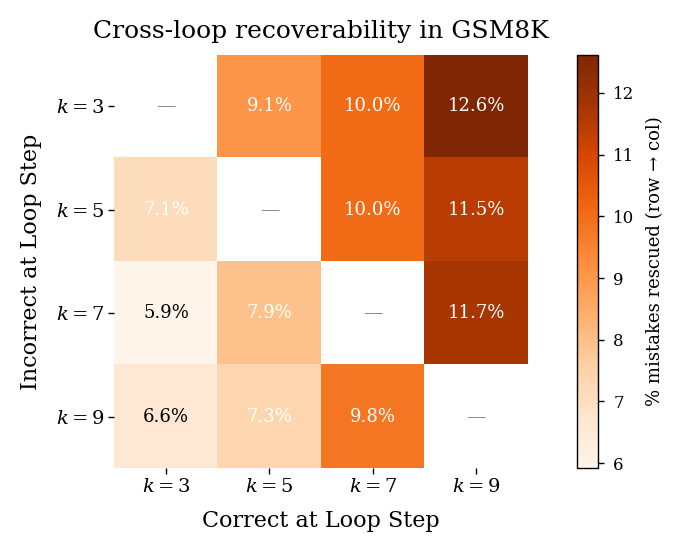


Absolute pairwise correction counts:
       $k=3$  $k=5$  $k=7$  $k=9$
$k=3$      0    104    115    145
$k=5$     80      0    113    129
$k=7$     65     87      0    129
$k=9$     71     79    105      0

As % of row-loop's mistakes:
       $k=3$  $k=5$  $k=7$  $k=9$
$k=3$    NaN   9.05  10.01  12.62
$k=5$   7.11    NaN  10.04  11.47
$k=7$   5.91   7.92    NaN  11.74
$k=9$   6.60   7.35   9.77    NaN


In [ ]:
# ---------------------------------------------------------------------------
# 2. Pairwise "correction" heatmap.
#    M[i, j] = # samples WRONG under L_i but CORRECT under L_j     (i = row, j = col)
#    Diagonal is set to NaN (a loop cannot rescue itself).
# ---------------------------------------------------------------------------
n = len(LOOP_KEYS)
M_count = np.zeros((n, n), dtype=int)
M_pct_of_wrong_i = np.full((n, n), np.nan)   # normalized by # wrongs in row i

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    n_wrong_i = int(wrong_mask[ki].sum())
    for j, kj in enumerate(LOOP_KEYS):
        if i == j:
            continue
        cnt = int((wrong_mask[ki] & right_mask[kj]).sum())
        M_count[i, j] = cnt
        if n_wrong_i:
            M_pct_of_wrong_i[i, j] = cnt / n_wrong_i * 100.0

# Double-column figure (~6.6in wide).
fig, axes = plt.subplots(1, 1, figsize=(6.6, 2.8))

def _heat(ax, mat, title, fmt, cmap, cbar_label):
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_xticklabels(LOOP_KEYS)
    ax.set_yticks(range(n)); ax.set_yticklabels(LOOP_KEYS)
    ax.set_xlabel("Correct at Loop Step", labelpad=5)
    ax.set_ylabel("Incorrect at Loop Step", labelpad=5)
    ax.set_title(title, pad=3)
    for i in range(n):
        for j in range(n):
            if i == j:
                ax.text(j, i, "—", ha="center", va="center", color="gray", fontsize=7)
            else:
                v = mat[i, j]
                if np.isnan(v):
                    continue
                ax.text(j, i, fmt.format(v), ha="center", va="center",
                        color="white" if v > np.nanmax(mat) * 0.55 else "black",
                        fontsize=6.5)
    ax.tick_params(length=2, pad=1.5)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label, fontsize=6.5)
    cb.ax.tick_params(labelsize=6, length=2)
    cb.outline.set_linewidth(0.5)

# _heat(axes[0], M_count.astype(float), "Corrections (absolute count)",
#       "{:.0f}", "Blues", "# wrong in row, right in col")
_heat(axes, M_pct_of_wrong_i,
      "",
      "{:.1f}%", "Oranges", "% mistakes rescued (row → col)")

# fig.suptitle("Cross-loop recoverability in GSM8K", fontsize=9, x=1, y=0.99)

axes.set_title(f"Cross-loop recoverability in GSM8K", fontsize=9)
# fig.tight_layout(pad=0.3, w_pad=1.5)
fig.tight_layout()

fig.savefig(PLOTS_DIR / "recoverability_pairwise_heatmap.pdf", bbox_inches="tight")
# fig.savefig(PLOTS_DIR / "recoverability_pairwise_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAbsolute pairwise correction counts:")
print(pd.DataFrame(M_count, index=LOOP_KEYS, columns=LOOP_KEYS))
print("\nAs % of row-loop's mistakes:")
print(pd.DataFrame(M_pct_of_wrong_i, index=LOOP_KEYS, columns=LOOP_KEYS).round(2))

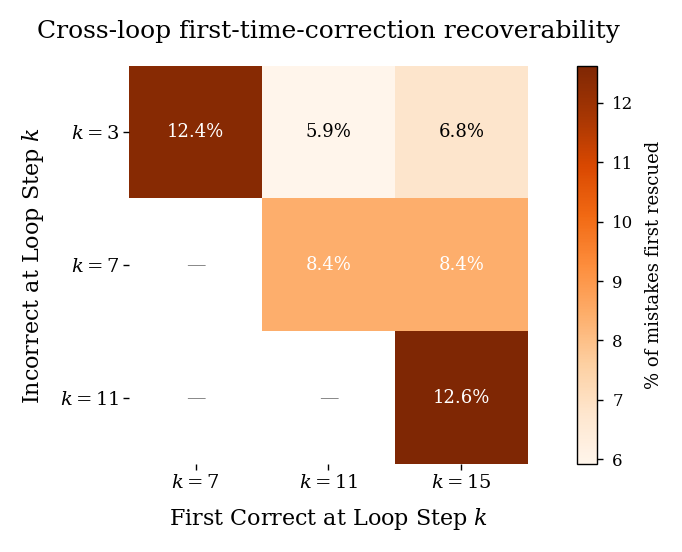


Absolute first-correction counts:
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0    143      68      78
$k=7$       0      0      91      91
$k=11$      0      0       0     140
$k=15$      0      0       0       0

As % of row-loop's mistakes:
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN  12.43    5.91    6.78
$k=7$     NaN    NaN    8.43    8.43
$k=11$    NaN    NaN     NaN   12.62
$k=15$    NaN    NaN     NaN     NaN


In [ ]:
# ---------------------------------------------------------------------------
# 2. Pairwise "first-correction" heatmap.
#    M[i, j] = # samples WRONG under L_i, WRONG under every L_k for i < k < j,
#              and CORRECT under L_j     (L_j = first loop after L_i to be correct)
#    Lower triangle + diagonal are NaN (no "later" loop to correct from).
# ---------------------------------------------------------------------------

n = len(LOOP_KEYS)

M_count = np.zeros((n, n), dtype=int)
M_pct_of_wrong_i = np.full((n, n), np.nan)

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    n_wrong_i = int(wrong_mask[ki].sum())

    for j, kj in enumerate(LOOP_KEYS):

        if j <= i:
            continue

        # Wrong under L_i,
        # wrong under every loop strictly between i and j,
        # right under L_j
        mask = wrong_mask[ki] & right_mask[kj]

        for m in range(i + 1, j):
            mask &= wrong_mask[LOOP_KEYS[m]]

        cnt = int(mask.sum())

        M_count[i, j] = cnt

        if n_wrong_i:
            M_pct_of_wrong_i[i, j] = cnt / n_wrong_i * 100.0


# ---------------------------------------------------------------------------
# Remove:
#   - first column
#   - last row
# ---------------------------------------------------------------------------

mat_view = M_pct_of_wrong_i[:-1, 1:]

x_labels = LOOP_KEYS[1:]    # remove first column label
y_labels = LOOP_KEYS[:-1]   # remove last row label


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(6.6, 2.8))


def _heat(ax, mat, title, fmt, cmap, cbar_label,
          x_labels=None, y_labels=None):

    rows, cols = mat.shape

    im = ax.imshow(mat, cmap=cmap)

    if x_labels is None:
        x_labels = list(range(cols))

    if y_labels is None:
        y_labels = list(range(rows))

    ax.set_xticks(range(cols))
    ax.set_xticklabels(x_labels)

    ax.set_yticks(range(rows))
    ax.set_yticklabels(y_labels)

    ax.set_xlabel("First Correct at Loop Step $k$", labelpad=5)
    ax.set_ylabel("Incorrect at Loop Step $k$", labelpad=5)

    ax.set_title(title, pad=3)

    vmax = np.nanmax(mat)

    for i in range(rows):
        for j in range(cols):

            # Map displayed coords back to original matrix coords
            orig_i = i
            orig_j = j + 1   # shifted because first column removed

            if orig_j <= orig_i:

                ax.text(
                    j, i, "—",
                    ha="center",
                    va="center",
                    color="gray",
                    fontsize=7
                )

            else:

                v = mat[i, j]

                if np.isnan(v):
                    continue

                ax.text(
                    j,
                    i,
                    fmt.format(v),
                    ha="center",
                    va="center",
                    color="white" if v > 7.2 else "black",
                    fontsize=6.5,
                )

    ax.tick_params(length=2, pad=1.5)

    for spine in ax.spines.values():
        spine.set_visible(False)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    cb.set_label(cbar_label, fontsize=6.5)
    cb.ax.tick_params(labelsize=6, length=2)
    cb.outline.set_linewidth(0.5)


_heat(
    ax,
    mat_view,
    "First corrections (% of row's mistakes)",
    "{:.1f}%",
    "Oranges",
    "% of mistakes first rescued",
    x_labels=x_labels,
    y_labels=y_labels,
)

ax.set_title(
    "Cross-loop first-time-correction recoverability",
    fontsize=9,
    pad=10
)

fig.tight_layout()

fig.savefig(
    PLOTS_DIR / "recoverability_first_pairwise_heatmap.pdf",
    bbox_inches="tight"
)

fig.savefig(
    PLOTS_DIR / "recoverability_first_pairwise_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------------------------
# Print tables
# ---------------------------------------------------------------------------

print("\nAbsolute first-correction counts:")
print(pd.DataFrame(M_count, index=LOOP_KEYS, columns=LOOP_KEYS))

print("\nAs % of row-loop's mistakes:")
print(
    pd.DataFrame(
        M_pct_of_wrong_i,
        index=LOOP_KEYS,
        columns=LOOP_KEYS
    ).round(2)
)

# Generated-token analysis across loops

How many tokens does each loop count generate on GSM8K, and how does the
distribution differ? Uses `metrics.num_tokens` (per response) and
`metrics.max_tokens_reached` (whether the response hit the decoding cap),
both already loaded into `df` as `toks_{L}` / `maxtok_{L}` in cell 5.

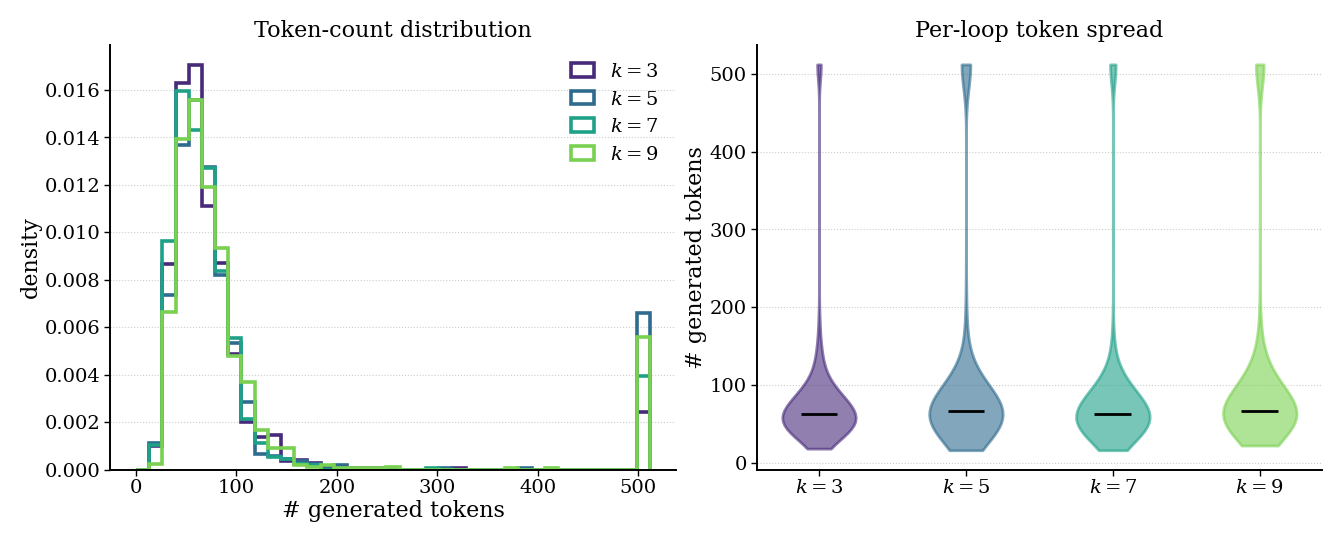

In [ ]:
# ---------------------------------------------------------------------------
# 8. Generated-token distribution across loops.
#    (a) overlaid (density-normalised) step histograms of #tokens / response
#    (b) violin plot of per-loop token spread (median marked)
# ---------------------------------------------------------------------------
LOOP_COLORS = [plt.cm.viridis(v) for v in np.linspace(0.12, 0.80, len(LOOP_KEYS))]
tok_data = {k: df[f"toks_{k}"].values for k in LOOP_KEYS}

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.6))

MAXTOK = int(max(v.max() for v in tok_data.values()))
bins = np.linspace(0, MAXTOK, 40)
for k, c in zip(LOOP_KEYS, LOOP_COLORS):
    axes[0].hist(tok_data[k], bins=bins, density=True, histtype="step",
                 lw=1.3, color=c, label=k)
axes[0].set_xlabel("# generated tokens", labelpad=1)
axes[0].set_ylabel("density", labelpad=1)
axes[0].set_title("Token-count distribution", pad=3)
axes[0].legend(frameon=False, handlelength=1.2)
_emnlp_ax(axes[0])

parts = axes[1].violinplot([tok_data[k] for k in LOOP_KEYS], showmedians=True,
                           showextrema=False)
for pc, c in zip(parts["bodies"], LOOP_COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.6); pc.set_edgecolor(c)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.0)
axes[1].set_xticks(range(1, len(LOOP_KEYS) + 1)); axes[1].set_xticklabels(LOOP_KEYS)
axes[1].set_ylabel("# generated tokens", labelpad=1)
axes[1].set_title("Per-loop token spread", pad=3)
_emnlp_ax(axes[1])

fig.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "token_distribution.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "token_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

       mean  median     std  pct_maxtok
L=3   80.69    62.0   83.11        3.18
L=5  106.31    66.0  128.11        8.64
L=7   87.88    62.0  102.16        5.16
L=9  103.40    67.0  119.28        7.35


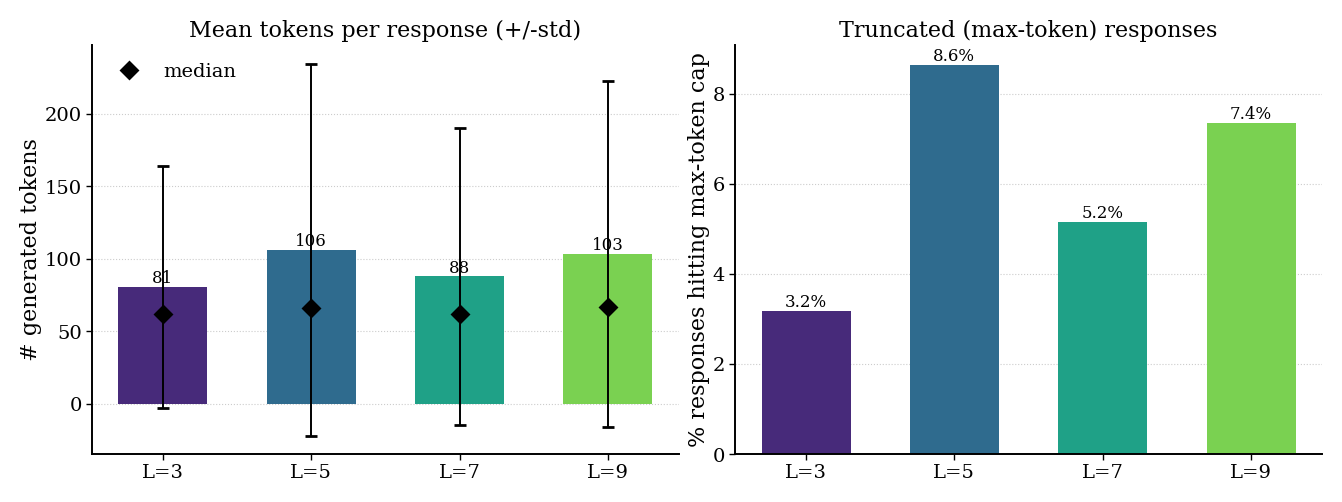

In [ ]:
# ---------------------------------------------------------------------------
# 9. Number of generated tokens per loop: mean (+/-std), median, and the
#    fraction of responses that hit the max-token decoding cap (truncated).
# ---------------------------------------------------------------------------
tok_summary = pd.DataFrame({
    "mean":       [df[f"toks_{k}"].mean()      for k in LOOP_KEYS],
    "median":     [df[f"toks_{k}"].median()    for k in LOOP_KEYS],
    "std":        [df[f"toks_{k}"].std()       for k in LOOP_KEYS],
    "pct_maxtok": [df[f"maxtok_{k}"].mean()*100 for k in LOOP_KEYS],
}, index=LOOP_KEYS)
print(tok_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.4))
x = np.arange(len(LOOP_KEYS))

axes[0].bar(x, tok_summary["mean"], yerr=tok_summary["std"], width=0.6,
            color=LOOP_COLORS, zorder=2, capsize=2, error_kw=dict(lw=0.7))
axes[0].plot(x, tok_summary["median"], "D", ms=4, color="black", label="median", zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(LOOP_KEYS)
axes[0].set_ylabel("# generated tokens", labelpad=1)
axes[0].set_title("Mean tokens per response (+/-std)", pad=3)
axes[0].legend(frameon=False)
for i, v in enumerate(tok_summary["mean"]):
    axes[0].text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[0])

axes[1].bar(x, tok_summary["pct_maxtok"], width=0.6, color=LOOP_COLORS, zorder=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(LOOP_KEYS)
axes[1].set_ylabel("% responses hitting max-token cap", labelpad=1)
axes[1].set_title("Truncated (max-token) responses", pad=3)
for i, v in enumerate(tok_summary["pct_maxtok"]):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[1])

fig.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "token_count_summary.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "token_count_summary.png", dpi=300, bbox_inches="tight")
plt.show()

# Generated-token analysis — samples ALL loops got right

Same two plots as above, but restricted to the subset of GSM8K samples that
every loop (L=3, 5, 7, 9) answered correctly. This controls for question
difficulty: differences in token count now reflect generation length on the
*same* set of solved problems rather than a different mix of easy/hard items.

In [ ]:
# Subset: samples correct under ALL loops.
df_all = df[df["n_correct"] == len(LOOP_KEYS)]
print(f"all-correct samples: {len(df_all)} / {len(df)} "
      f"({len(df_all)/len(df)*100:.1f}%)")

all-correct samples: 54 / 1319 (4.1%)


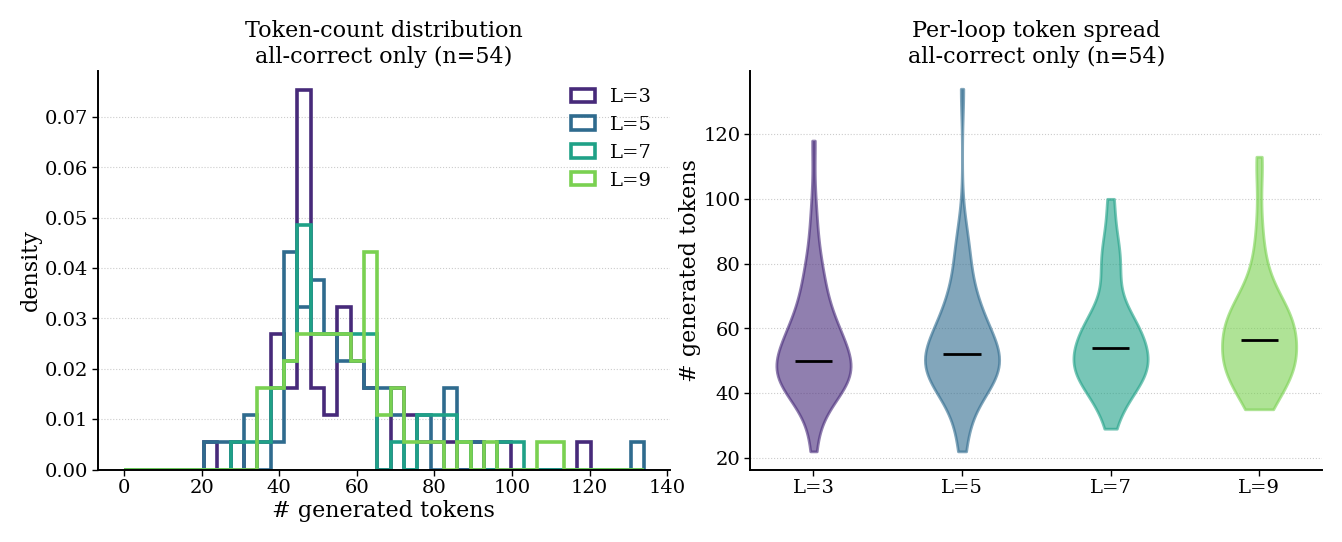

In [ ]:
# ---------------------------------------------------------------------------
# 10. Token distribution across loops -- all-correct subset only.
# ---------------------------------------------------------------------------
tok_data = {k: df_all[f"toks_{k}"].values for k in LOOP_KEYS}
SUFFIX = f"all-correct only (n={len(df_all)})"

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.6))

MAXTOK = int(max(v.max() for v in tok_data.values()))
bins = np.linspace(0, MAXTOK, 40)
for k, c in zip(LOOP_KEYS, LOOP_COLORS):
    axes[0].hist(tok_data[k], bins=bins, density=True, histtype="step",
                 lw=1.3, color=c, label=k)
axes[0].set_xlabel("# generated tokens", labelpad=1)
axes[0].set_ylabel("density", labelpad=1)
axes[0].set_title(f"Token-count distribution\n{SUFFIX}", pad=3)
axes[0].legend(frameon=False, handlelength=1.2)
_emnlp_ax(axes[0])

parts = axes[1].violinplot([tok_data[k] for k in LOOP_KEYS], showmedians=True,
                           showextrema=False)
for pc, c in zip(parts["bodies"], LOOP_COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.6); pc.set_edgecolor(c)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.0)
axes[1].set_xticks(range(1, len(LOOP_KEYS) + 1)); axes[1].set_xticklabels(LOOP_KEYS)
axes[1].set_ylabel("# generated tokens", labelpad=1)
axes[1].set_title(f"Per-loop token spread\n{SUFFIX}", pad=3)
_emnlp_ax(axes[1])

fig.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "token_distribution_allcorrect.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "token_distribution_allcorrect.png", dpi=300, bbox_inches="tight")
plt.show()

      mean  median    std  pct_maxtok
L=3  55.57    50.0  17.23         0.0
L=5  55.85    52.0  18.02         0.0
L=7  56.89    54.0  15.87         0.0
L=9  58.54    56.5  16.35         0.0


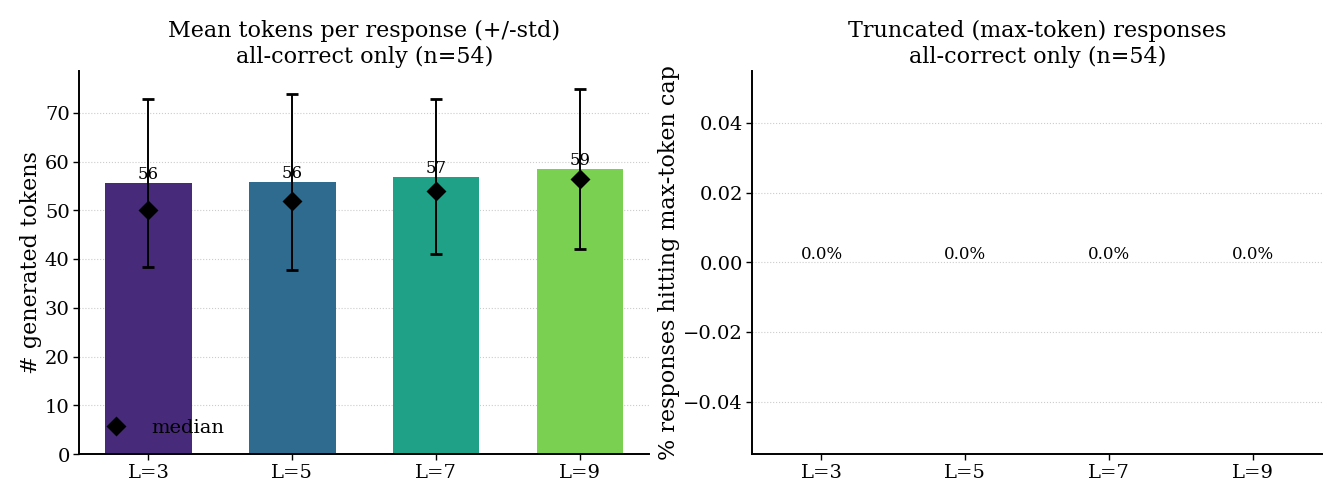

In [ ]:
# ---------------------------------------------------------------------------
# 11. Number of generated tokens per loop -- all-correct subset only.
#     (Note: on this subset no response hits the max-token cap, so the right
#      panel is trivially 0% -- kept for parity with the full-set figure.)
# ---------------------------------------------------------------------------
tok_summary = pd.DataFrame({
    "mean":       [df_all[f"toks_{k}"].mean()      for k in LOOP_KEYS],
    "median":     [df_all[f"toks_{k}"].median()    for k in LOOP_KEYS],
    "std":        [df_all[f"toks_{k}"].std()       for k in LOOP_KEYS],
    "pct_maxtok": [df_all[f"maxtok_{k}"].mean()*100 for k in LOOP_KEYS],
}, index=LOOP_KEYS)
print(tok_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.4))
x = np.arange(len(LOOP_KEYS))

axes[0].bar(x, tok_summary["mean"], yerr=tok_summary["std"], width=0.6,
            color=LOOP_COLORS, zorder=2, capsize=2, error_kw=dict(lw=0.7))
axes[0].plot(x, tok_summary["median"], "D", ms=4, color="black", label="median", zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(LOOP_KEYS)
axes[0].set_ylabel("# generated tokens", labelpad=1)
axes[0].set_title(f"Mean tokens per response (+/-std)\n{SUFFIX}", pad=3)
axes[0].legend(frameon=False)
for i, v in enumerate(tok_summary["mean"]):
    axes[0].text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[0])

axes[1].bar(x, tok_summary["pct_maxtok"], width=0.6, color=LOOP_COLORS, zorder=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(LOOP_KEYS)
axes[1].set_ylabel("% responses hitting max-token cap", labelpad=1)
axes[1].set_title(f"Truncated (max-token) responses\n{SUFFIX}", pad=3)
for i, v in enumerate(tok_summary["pct_maxtok"]):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[1])

fig.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "token_count_summary_allcorrect.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "token_count_summary_allcorrect.png", dpi=300, bbox_inches="tight")
plt.show()

# Generated-token analysis — per-loop correct samples

Same two plots, but each loop's distribution is taken over the samples *that
loop itself* answered correctly (not necessarily the same samples across
loops, and not requiring agreement). This answers: "when loop L gets the
answer right, how many tokens does it spend?" Note each loop therefore has a
different sample size (its own accuracy count).

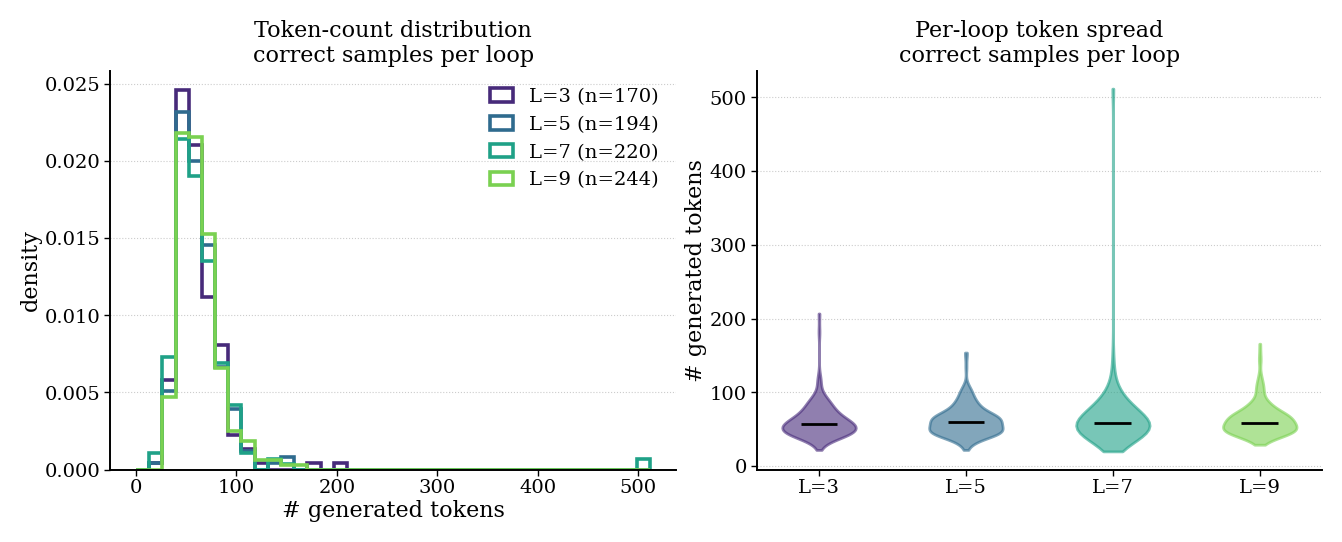

In [ ]:
# ---------------------------------------------------------------------------
# 12. Token distribution -- per-loop correct samples (each loop's own correct set).
# ---------------------------------------------------------------------------
tok_data = {k: df.loc[df[f"em_{k}"] == 1, f"toks_{k}"].values for k in LOOP_KEYS}
ns = {k: len(v) for k, v in tok_data.items()}
SUFFIX = "correct samples per loop"

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.6))
MAXTOK = int(max(v.max() for v in tok_data.values()))
bins = np.linspace(0, MAXTOK, 40)
for k, c in zip(LOOP_KEYS, LOOP_COLORS):
    axes[0].hist(tok_data[k], bins=bins, density=True, histtype="step",
                 lw=1.3, color=c, label=f"{k} (n={ns[k]})")
axes[0].set_xlabel("# generated tokens", labelpad=1)
axes[0].set_ylabel("density", labelpad=1)
axes[0].set_title(f"Token-count distribution\n{SUFFIX}", pad=3)
axes[0].legend(frameon=False, handlelength=1.2)
_emnlp_ax(axes[0])

parts = axes[1].violinplot([tok_data[k] for k in LOOP_KEYS], showmedians=True,
                           showextrema=False)
for pc, c in zip(parts["bodies"], LOOP_COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.6); pc.set_edgecolor(c)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.0)
axes[1].set_xticks(range(1, len(LOOP_KEYS) + 1)); axes[1].set_xticklabels(LOOP_KEYS)
axes[1].set_ylabel("# generated tokens", labelpad=1)
axes[1].set_title(f"Per-loop token spread\n{SUFFIX}", pad=3)
_emnlp_ax(axes[1])

fig.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "token_distribution_correct_per_loop.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "token_distribution_correct_per_loop.png", dpi=300, bbox_inches="tight")
plt.show()

      mean  median    std  pct_maxtok    n
L=3  61.66    57.0  23.16        0.00  170
L=5  62.09    59.5  20.48        0.00  194
L=7  65.25    58.0  47.70        0.91  220
L=9  63.28    59.0  21.30        0.00  244


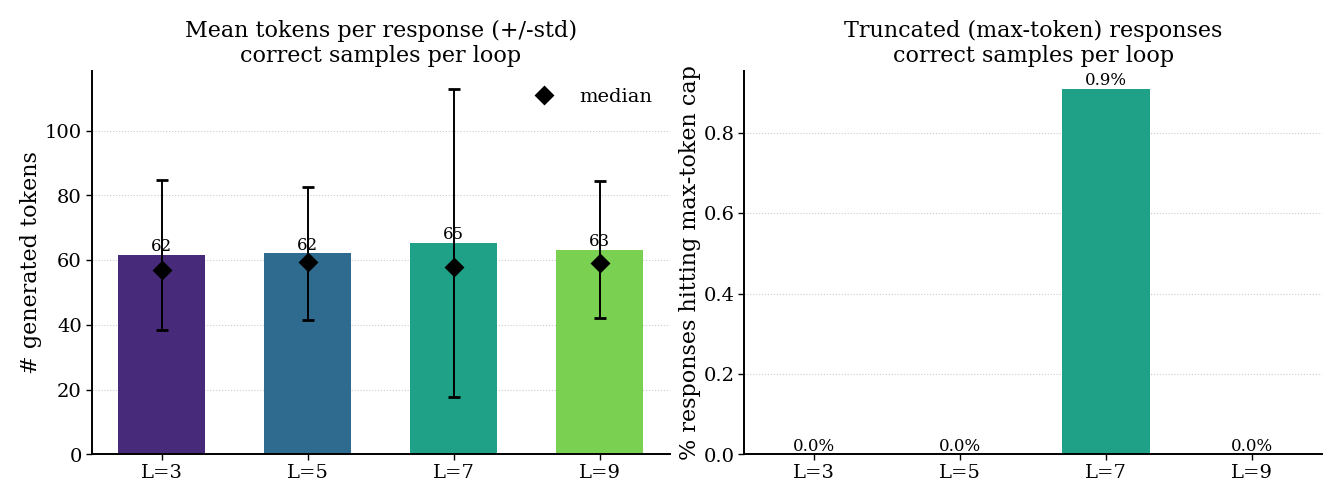

In [ ]:
# ---------------------------------------------------------------------------
# 13. Number of generated tokens -- per-loop correct samples.
# ---------------------------------------------------------------------------
tok_summary = pd.DataFrame({
    "mean":       [tok_data[k].mean()               for k in LOOP_KEYS],
    "median":     [np.median(tok_data[k])           for k in LOOP_KEYS],
    "std":        [tok_data[k].std(ddof=1)          for k in LOOP_KEYS],
    "pct_maxtok": [df.loc[df[f"em_{k}"] == 1, f"maxtok_{k}"].mean()*100 for k in LOOP_KEYS],
    "n":          [ns[k]                            for k in LOOP_KEYS],
}, index=LOOP_KEYS)
print(tok_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.4))
x = np.arange(len(LOOP_KEYS))

axes[0].bar(x, tok_summary["mean"], yerr=tok_summary["std"], width=0.6,
            color=LOOP_COLORS, zorder=2, capsize=2, error_kw=dict(lw=0.7))
axes[0].plot(x, tok_summary["median"], "D", ms=4, color="black", label="median", zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(LOOP_KEYS)
axes[0].set_ylabel("# generated tokens", labelpad=1)
axes[0].set_title(f"Mean tokens per response (+/-std)\n{SUFFIX}", pad=3)
axes[0].legend(frameon=False)
for i, v in enumerate(tok_summary["mean"]):
    axes[0].text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[0])

axes[1].bar(x, tok_summary["pct_maxtok"], width=0.6, color=LOOP_COLORS, zorder=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(LOOP_KEYS)
axes[1].set_ylabel("% responses hitting max-token cap", labelpad=1)
axes[1].set_title(f"Truncated (max-token) responses\n{SUFFIX}", pad=3)
for i, v in enumerate(tok_summary["pct_maxtok"]):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[1])

fig.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "token_count_summary_correct_per_loop.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "token_count_summary_correct_per_loop.png", dpi=300, bbox_inches="tight")
plt.show()

In [158]:
x_labels

['$k=7$', '$k=11$', '$k=15$']

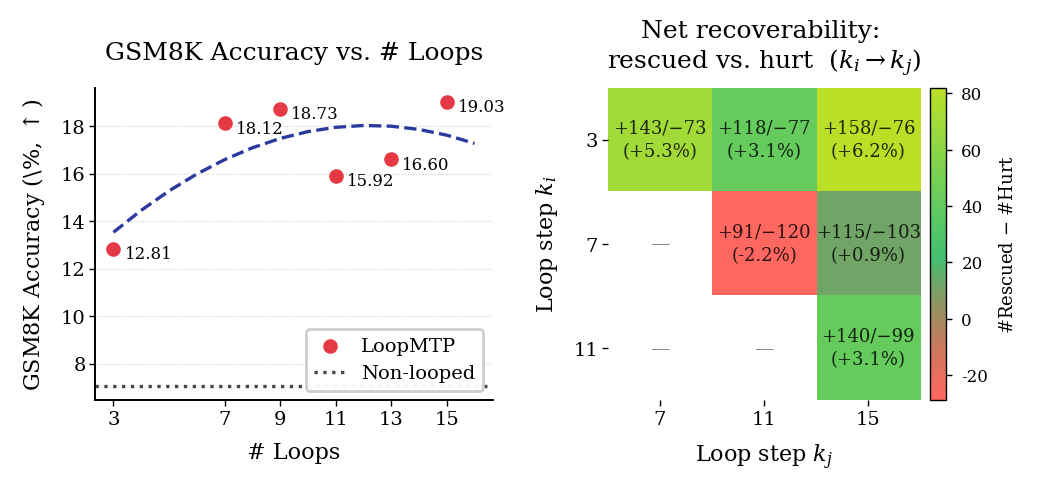


Total samples (denominator for %): 1319

Rescued counts (wrong@row -> right@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0    143     118     158
$k=7$       0      0      91     115
$k=11$      0      0       0     140
$k=15$      0      0       0       0

Hurt counts (right@row -> wrong@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0     73      77      76
$k=7$       0      0     120     103
$k=11$      0      0       0      99
$k=15$      0      0       0       0

Net (rescued - hurt):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   70.0    41.0    82.0
$k=7$     NaN    NaN   -29.0    12.0
$k=11$    NaN    NaN     NaN    41.0
$k=15$    NaN    NaN     NaN     NaN

Rescued % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN  10.84    8.95   11.98
$k=7$     NaN    NaN    6.90    8.72
$k=11$    NaN    NaN     NaN   10.61
$k=15$    NaN    NaN     NaN     NaN

Hurt % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   5.53   

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        8,
    "axes.titlesize":   8,
    "axes.labelsize":   8,
    "legend.fontsize":  7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "lines.linewidth":  1.2,
    "figure.dpi":       200,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

# ─────────────────────────────────────────────────────────────────────────────
# Two-panel figure: (a) accuracy extrapolation   (b) perplexity @ 5B tokens
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax) = plt.subplots(1, 2, figsize=(5, 2.2))

# ── Subplot (a): GSM8K accuracy vs. # loops ──────────────────────────────────
loops_data   = np.array([3, 7, 9, 11, 13, 15])
mtp_acc_data = np.array([12.813, 18.12, 18.726, 15.921, 16.603, 19.03])

coeffs = np.polyfit(loops_data, mtp_acc_data, 2)  # slope, intercept
poly   = np.poly1d(coeffs)

loops_extrap   = np.arange(3, 17)
mtp_acc_extrap = poly(loops_extrap)

ax1.scatter(loops_data, mtp_acc_data, color="#e63946", s=18, zorder=5, label="LoopMTP")
for l, a in zip(loops_data, mtp_acc_data):
    ax1.annotate(f"{a:.2f}", (l + 0.1, a - 0.755), textcoords="offset points", xytext=(3, 3), fontsize=6,
    )

non_looped_baseline = 7.05
ax1.axhline(non_looped_baseline, color="#48464D", linestyle=":", linewidth=1.2, label="Non-looped")

ax1.plot(loops_extrap, mtp_acc_extrap, "--", color="#2b3a9e", linewidth=1.2,
)
        #  label=f"$y = {coeffs[0]:.2f}x^2 + {coeffs[1]:.2f}x + {coeffs[2]:.2f}$")

ax1.set_xlabel("# Loops", labelpad=5)
ax1.set_ylabel("GSM8K Accuracy (\\%, $\\uparrow$)", labelpad=5)
# ax1.set_xticks(loops_extrap[::2])
ax1.set_xticks(loops_data)
ax1.tick_params(length=2, pad=1.5)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax1.set_axisbelow(True)
# ax1.set_title("(a) Accuracy extrapolation", pad=3)
ax1.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", handlelength=1.6, loc="lower right")

ax1.set_title("GSM8K Accuracy vs. # Loops", fontsize=9, pad=10)

# fig.tight_layout()
# Path("./plots").mkdir(exist_ok=True)
# fig.savefig("./plots/math_expert_extrapolation_wo_ppl.pdf", bbox_inches="tight")





from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ---------------------------------------------------------------------------
# 3. Pairwise NET recoverability heatmap (rescued vs hurt).
# ---------------------------------------------------------------------------

n = len(LOOP_KEYS)
N = len(df)

M_rescued = np.zeros((n, n), dtype=int)
M_hurt    = np.zeros((n, n), dtype=int)
M_net     = np.full((n, n), np.nan)

M_rescued_pct = np.full((n, n), np.nan)
M_hurt_pct    = np.full((n, n), np.nan)

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    for j, kj in enumerate(LOOP_KEYS):
        if j <= i:
            continue
        r = int((wrong_mask[ki] & right_mask[kj]).sum())
        h = int((right_mask[ki] & wrong_mask[kj]).sum())
        M_rescued[i, j] = r
        M_hurt[i, j]    = h
        M_net[i, j]     = r - h
        M_rescued_pct[i, j] = r / N * 100.0
        M_hurt_pct[i, j]    = h / N * 100.0


# ---------------------------------------------------------------------------
# Drop the always-empty first column (j=0) and last row (i=n-1).
# ---------------------------------------------------------------------------
net_view = M_net[:-1, 1:]
x_labels = LOOP_KEYS[1:]
x_labels = [x.replace("$", "").replace("k=" , "") for x in x_labels]
y_labels = LOOP_KEYS[:-1]
y_labels = [y.replace("$", "").replace("k=" , "") for y in y_labels]

vmin = float(np.nanmin(net_view))
vmax = float(np.nanmax(net_view))
vmin = min(vmin, -1e-9)
vmax = max(vmax,  1e-9)

# ---------------------------------------------------------------------------
# Linear normalization (NOT TwoSlopeNorm). Zero sits at its true proportional
# position on the bar -> short red section, long green section.
# ---------------------------------------------------------------------------
norm = Normalize(vmin=vmin, vmax=vmax)

# Build the colormap so its red->green transition aligns with 0 in data space.
zero_frac = (0.0 - vmin) / (vmax - vmin)   # fraction of bar below 0
n_total = 256
n_neg = max(1, int(round(zero_frac * n_total)))
n_pos = n_total - n_neg

pos_colors = plt.cm.viridis(np.linspace(0.7, 0.9, 80))
neg_anchor = pos_colors[0]
neg_colors = LinearSegmentedColormap.from_list(
    "neg", ["#ff0d009f", neg_anchor]
)(np.linspace(0, 1, n_neg))
cmap = LinearSegmentedColormap.from_list(
    "viridis_div_red", np.vstack([neg_colors, pos_colors])
)

# ---------------------------------------------------------------------------
# Plot.
# ---------------------------------------------------------------------------
# fig, ax = plt.subplots(1, 1, figsize=(3.3, 2.5))
im = ax.imshow(net_view, cmap=cmap, norm=norm)

rows, cols = net_view.shape
ax.set_xticks(range(cols)); ax.set_xticklabels(x_labels)
ax.set_yticks(range(rows)); ax.set_yticklabels(y_labels)
ax.set_xlabel(r"Loop step $k_j$", labelpad=5)
ax.set_ylabel(r"Loop step $k_i$", labelpad=5)
ax.set_title("Net recoverability: \nrescued vs. hurt  ($k_i \\to k_j$)",
             fontsize=9, pad=7)

for i in range(rows):
    for j in range(cols):
        orig_i = i
        orig_j = j + 1
        if orig_j <= orig_i:
            ax.text(j, i, "—", ha="center", va="center",
                    color="gray", fontsize=7)
            continue
        net = M_net[orig_i, orig_j]
        if np.isnan(net):
            continue
        txt_color = "#000000D2"
        net_pct = net / N * 100.0
        ax.text(
            j, i,
            f"+{M_rescued[orig_i, orig_j]}/−{M_hurt[orig_i, orig_j]}\n"
            f"({net_pct:+.1f}%)",
            ha="center", va="center", color=txt_color, fontsize=6.5,
            linespacing=1.4,
        )

ax.tick_params(length=2, pad=1.5)
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------------------------------------------------------------
# Colorbar: evenly spaced ticks every `tick_step` units across the whole bar.
# Zero is naturally included; spacing is uniform in data units.
# ---------------------------------------------------------------------------
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.025)
cb.set_label("#Rescued $-$ #Hurt", fontsize=6.5)

tick_step = 20   # change to 10 / 25 to taste
cb.ax.yaxis.set_major_locator(MultipleLocator(tick_step))
cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}"))
cb.ax.tick_params(labelsize=6, length=2)
cb.outline.set_linewidth(0.5)

# set the wite space left to right to the smallest possible
fig.tight_layout(pad=0.0, w_pad=-1.5)

fig.savefig(PLOTS_DIR / "recoverability_net_pairwise_heatmap_GSM_accuracy.pdf",
            bbox_inches="tight")
fig.savefig(PLOTS_DIR / "recoverability_net_pairwise_heatmap_small.png",
            dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# Print tables
# ---------------------------------------------------------------------------
idx, col = LOOP_KEYS, LOOP_KEYS
print(f"\nTotal samples (denominator for %): {N}")
print("\nRescued counts (wrong@row -> right@col):")
print(pd.DataFrame(M_rescued, index=idx, columns=col))
print("\nHurt counts (right@row -> wrong@col):")
print(pd.DataFrame(M_hurt, index=idx, columns=col))
print("\nNet (rescued - hurt):")
print(pd.DataFrame(M_net, index=idx, columns=col))
print("\nRescued % (of all samples):")
print(pd.DataFrame(M_rescued_pct, index=idx, columns=col).round(2))
print("\nHurt % (of all samples):")
print(pd.DataFrame(M_hurt_pct, index=idx, columns=col).round(2))



Total samples (denominator for %): 1319

Rescued counts (wrong@row -> right@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0    143     118     158
$k=7$       0      0      91     115
$k=11$      0      0       0     140
$k=15$      0      0       0       0

Hurt counts (right@row -> wrong@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0     73      77      76
$k=7$       0      0     120     103
$k=11$      0      0       0      99
$k=15$      0      0       0       0

Net (rescued - hurt):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   70.0    41.0    82.0
$k=7$     NaN    NaN   -29.0    12.0
$k=11$    NaN    NaN     NaN    41.0
$k=15$    NaN    NaN     NaN     NaN

Rescued % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN  10.84    8.95   11.98
$k=7$     NaN    NaN    6.90    8.72
$k=11$    NaN    NaN     NaN   10.61
$k=15$    NaN    NaN     NaN     NaN

Hurt % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   5.53   